In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
import country_converter as coco
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Učitavanje glavnog dataseta
df = pd.read_csv('archive/GCB2022v27_MtCO2_flat.csv')

# Provera da li je učitano
print(df.shape)  # broj redova i kolona
print(df.head())  # prvih 5 redova

(63104, 11)
       Country ISO 3166-1 alpha-3  Year  Total  Coal  Oil  Gas  Cement  \
0  Afghanistan                AFG  1750    0.0   NaN  NaN  NaN     NaN   
1  Afghanistan                AFG  1751    0.0   NaN  NaN  NaN     NaN   
2  Afghanistan                AFG  1752    0.0   NaN  NaN  NaN     NaN   
3  Afghanistan                AFG  1753    0.0   NaN  NaN  NaN     NaN   
4  Afghanistan                AFG  1754    0.0   NaN  NaN  NaN     NaN   

   Flaring  Other  Per Capita  
0      NaN    NaN         NaN  
1      NaN    NaN         NaN  
2      NaN    NaN         NaN  
3      NaN    NaN         NaN  
4      NaN    NaN         NaN  


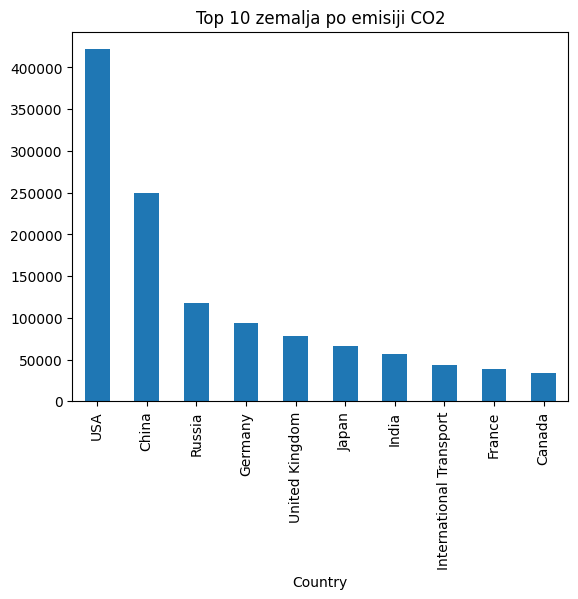

In [3]:
# Grafikon top 10 drzava
top10 = df[df['Country'] != 'Global'].groupby('Country')['Total'].sum().sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.title('Top 10 zemalja po emisiji CO2')
plt.show()


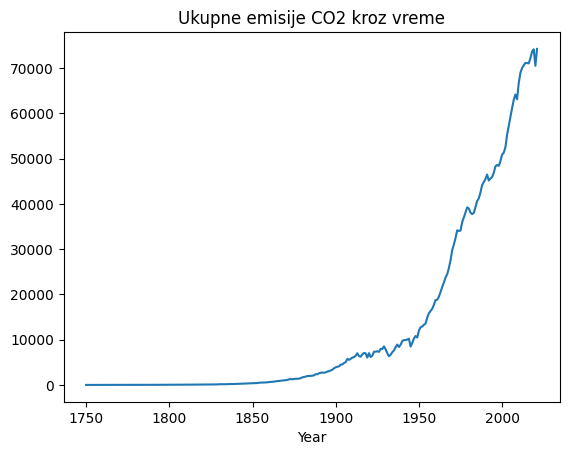

In [4]:
godisnje = df.groupby('Year')['Total'].sum()
godisnje.plot()
plt.title('Ukupne emisije CO2 kroz vreme')
plt.show()

In [5]:
#Filtriramo glavni dataset na period od 1925. jer su raniji podaci nepotpuni
df_1925 = df[df['Year'] >= 1925].copy()

In [6]:
# Nedostajuće vrednosti po kolonama
missing = pd.DataFrame({
    'Broj nedostajućih': df_1925.isnull().sum(),
    'Procenat (%)': (df_1925.isnull().sum() / len(df_1925) * 100).round(2)
})

missing = missing[missing['Broj nedostajućih'] > 0].sort_values('Procenat (%)', ascending=False)

print(f"Dimenzije dataseta: {df_1925.shape}")
print(f"\nUkupno nedostajućih vrednosti: {df_1925.isnull().sum().sum()}")
print(f"\nKolone sa nedostajućim vrednostima:")
print(missing.to_string())

Dimenzije dataseta: (22504, 11)

Ukupno nedostajućih vrednosti: 52836

Kolone sa nedostajućim vrednostima:
                    Broj nedostajućih  Procenat (%)
Other                           20905         92.89
Per Capita                       5297         23.54
Flaring                          5264         23.39
Gas                              5239         23.28
Coal                             5239         23.28
Oil                              5167         22.96
Cement                           5118         22.74
ISO 3166-1 alpha-3                582          2.59
Total                              25          0.11


In [7]:
# Zbog ogromnog broja nedostajucih vrednosti (92.89%) izbacujemo kolonu Other
df_1925 = df_1925.drop(columns=['Other'])
print(df_1925.shape)
print(df_1925.columns.tolist())

(22504, 10)
['Country', 'ISO 3166-1 alpha-3', 'Year', 'Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']


In [8]:
# Provera da li nedostaju isti redovi
cols = ['Per Capita', 'Flaring', 'Gas', 'Coal', 'Oil', 'Cement']
print(df_1925[cols].isnull().all(axis=1).sum())

3091


In [9]:
# Provera koji redovi nemaju ni jednu vrednost emisije (koje godine i koje drzave)
prazni = df_1925[df_1925[cols].isnull().all(axis=1)]

print(prazni['Country'].value_counts().head(20))  # koje zemlje
print(prazni['Year'].value_counts().sort_index())  # koje godine

Country
Anguilla                    25
Angola                      25
Antigua and Barbuda         25
Antarctica                  25
Burkina Faso                25
British Virgin Islands      25
Bahamas                     25
Belize                      25
Botswana                    25
Bhutan                      25
Bermuda                     25
Benin                       25
Cook Islands                25
Congo                       25
Comoros                     25
Christmas Island            25
Chad                        25
Central African Republic    25
Cape Verde                  25
Burundi                     25
Name: count, dtype: int64
Year
1925    141
1926    137
1927    135
1928    131
1929    131
1930    130
1931    127
1932    126
1933    122
1934    123
1935    123
1936    123
1937    123
1938    122
1939    120
1940    122
1941    124
1942    127
1943    119
1944    120
1945    119
1946    117
1947    112
1948    110
1949    107
Name: count, dtype: int64


In [10]:
# Ucitavamo drugi dataset direktno sa interneta (Our World In Data - OWID)
# Prvi dataset ima samo emisije po izvoru, tako da smo nasle dodatan koji ima socioekonomske podatke kao sto su BDP, populacija...
# ti podaci su nam potrebi kao feature-i jer su nezavisni od Target-a (Total)
owid = pd.read_csv('https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv')
print(owid.shape)
print(owid.columns.tolist())

c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\ssl.py:524: UserWarning: Bad certificate in Windows certificate store: not enough data: cadata does not contain a certificate (_ssl.c:4216)
  warnings.warn(f"Bad certificate in Windows certificate store: {exc!s}")


(50411, 79)
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_p

In [11]:
# Potrebne kolone koje izvlačimo iz OWID-a
extra_cols = ['country', 'year',
              'gdp',
              'population', 
              'energy_per_capita',
              'primary_energy_consumption',
              'co2_per_gdp',
              'methane',
              'nitrous_oxide']

owid_subset = owid[extra_cols]

In [12]:
# Ispravljanje naziva kako bi se poklopili
df_1925['Country'] = df_1925['Country'].replace({
    'Czech Republic': 'Czechia',
    'Viet Nam': 'Vietnam'
})


In [13]:
# Spajanje prvog i drugog dataseta (drzava + godina)
# Radimo left join gde zadrzavamo sve podatke iz prvog dataseta, cak i ako za neku drzavu/godinu nema OWID podataka
df_merged = df_1925.merge(owid_subset,
                          left_on=['Country', 'Year'],
                          right_on=['country', 'year'],
                          how='left')


In [14]:
# Ukloni duplirane kolone 
df_merged = df_merged.drop(columns=['country', 'year'])

print(f"Originalni dataset: {df_1925.shape}")
print(f"Nakon spajanja: {df_merged.shape}")

print(f"\nNedostajuce vrednosti novih kolona:")
print(df_merged[['gdp', 'population', 'energy_per_capita', 
                  'primary_energy_consumption', 'co2_per_gdp',
                  'methane', 'nitrous_oxide']].isnull().sum())

Originalni dataset: (22504, 10)
Nakon spajanja: (22504, 17)

Nedostajuce vrednosti novih kolona:
gdp                           10335
population                     3306
energy_per_capita             13591
primary_energy_consumption    13549
co2_per_gdp                   10564
methane                        3880
nitrous_oxide                  3686
dtype: int64


In [15]:
# Ispisujemo sve drzave radi provere da li su ostale neke drzave koje su se raspale, kolonije, teritorije...
print(sorted(df_merged['Country'].unique()))

['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire, Saint Eustatius and Saba', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Christmas Island', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao', 'Cyprus', 'Czechia', "Côte d'Ivoire", 'Democratic Republic of the Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Ethiopia', 'Faeroe Islands', 'Fiji', 'Finland', 'France', 'French Equatorial Africa', 'French Guiana', 'F

In [16]:
# Brisemo sve sto nije drzava
nije_drzava = [
    
    'Global', 'International Transport', 'Kuwaiti Oil Fires',
    
    
    'French Equatorial Africa', 'French West Africa', 
    'Leeward Islands', 'Ryukyu Islands',
    'St. Kitts-Nevis-Anguilla',  
    'Panama Canal Zone',                    
    
    
    'Anguilla', 'Antarctica', 'Bermuda',
    'Bonaire, Saint Eustatius and Saba', 'British Virgin Islands',
    'Christmas Island', 'Cook Islands', 'Curaçao',
    'Faeroe Islands', 'French Guiana', 'French Polynesia',
    'Greenland', 'Guadeloupe', 'Hong Kong', 'Macao',
    'Martinique', 'Mayotte', 'Montserrat', 'New Caledonia',
    'Niue', 'Puerto Rico', 'Réunion', 'Saint Helena',
    'Saint Pierre and Miquelon', 'Sint Maarten (Dutch part)',
    'Taiwan',                     
    'Turks and Caicos Islands', 'Wallis and Futuna Islands',
]

df_clean = df_merged[~df_merged['Country'].isin(nije_drzava)]

print(f"Pre: {df_merged['Country'].nunique()} entiteta")
print(f"Posle: {df_clean['Country'].nunique()} entiteta")
print(f"Ukupno redova: {df_clean.shape}")

Pre: 232 entiteta
Posle: 195 entiteta
Ukupno redova: (18915, 17)


In [17]:
# Ponovna provera nedostajucih vrednosti, ali na cistijem datasetu
missing = pd.DataFrame({
    'Broj nedostajućih': df_clean.isnull().sum(),
    'Procenat (%)': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing = missing[missing['Broj nedostajućih'] > 0].sort_values('Procenat (%)', ascending=False)

print(f"Dimenzije dataseta: {df_clean.shape}")
print(f"Ukupno nedostajućih vrednosti: {df_clean.isnull().sum().sum()}")
print(f"\nKolone sa nedostajućim vrednostima:")
print(missing.to_string())

Dimenzije dataseta: (18915, 17)
Ukupno nedostajućih vrednosti: 60312

Kolone sa nedostajućim vrednostima:
                            Broj nedostajućih  Procenat (%)
primary_energy_consumption              10620         56.15
energy_per_capita                       10620         56.15
co2_per_gdp                              7135         37.72
gdp                                      6906         36.51
Per Capita                               4325         22.87
Cement                                   3530         18.66
Coal                                     3524         18.63
Flaring                                  3524         18.63
Oil                                      3524         18.63
Gas                                      3524         18.63
methane                                  1067          5.64
nitrous_oxide                             970          5.13
population                                946          5.00
ISO 3166-1 alpha-3                         97         

In [18]:
print(df_clean[df_clean['energy_per_capita'].isnull()]['Year'].describe())
print(df_clean[df_clean['gdp'].isnull()]['Year'].describe())

count    10620.000000
mean      1953.706121
std         19.490810
min       1925.000000
25%       1938.000000
50%       1952.000000
75%       1966.000000
max       2021.000000
Name: Year, dtype: float64
count    6906.000000
mean     1958.286418
std        27.207209
min      1925.000000
25%      1936.000000
50%      1948.000000
75%      1977.000000
max      2021.000000
Name: Year, dtype: float64


In [19]:
#Deskriptivna statistika
df_clean.describe()


,Year,Total,Coal,Oil,Gas,Cement,Flaring,Per Capita,gdp,population,energy_per_capita,primary_energy_consumption,co2_per_gdp,methane,nitrous_oxide
count,18915.00000,18915.000000,15391.000000,15391.000000,15391.000000,15385.000000,15391.000000,14590.000000,1.200900e+04,1.796900e+04,8295.000000,8295.000000,11780.000000,17848.000000,17945.000000
mean,1973.00000,82.699459,44.745170,35.782607,16.387108,2.900455,1.197243,3.942485,2.315724e+11,2.166575e+07,23379.238266,509.893737,0.370802,27.278610,7.788623
std,28.00074,453.373537,284.082252,163.107453,88.370439,24.984150,5.203581,6.602530,8.636746e+11,9.339977e+07,33077.667892,1862.264310,0.850693,81.512197,24.897841
min,1925.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.998000e+07,2.378000e+03,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.00000,0.084272,0.000000,0.408524,0.000000,0.000000,0.000000,0.251209,8.519696e+09,8.439620e+05,2387.508500,8.547500,0.131000,0.979500,0.270000
50%,1973.00000,2.495184,0.245148,2.517168,0.000000,0.155618,0.000000,1.379301,3.041683e+10,3.980430e+06,10105.646000,57.846000,0.247000,5.658500,1.666000
75%,1997.00000,24.232312,6.857268,15.438380,2.427400,1.045800,0.000244,5.362107,1.346739e+11,1.157493e+07,32404.730500,329.012500,0.456000,20.065500,6.173000
max,2021.00000,11472.369171,7955.985419,2644.236598,1673.999100,858.232613,88.383147,120.383435,2.618060e+13,1.426437e+09,318559.688000,43847.180000,82.599000,1450.486000,466.877000


In [20]:
#Osnovne informacije o datasetu
df_clean.info()
df_clean.shape


<class 'pandas.core.frame.DataFrame'>
Index: 18915 entries, 0 to 22309
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     18915 non-null  object 
 1   ISO 3166-1 alpha-3          18818 non-null  object 
 2   Year                        18915 non-null  int64  
 3   Total                       18915 non-null  float64
 4   Coal                        15391 non-null  float64
 5   Oil                         15391 non-null  float64
 6   Gas                         15391 non-null  float64
 7   Cement                      15385 non-null  float64
 8   Flaring                     15391 non-null  float64
 9   Per Capita                  14590 non-null  float64
 10  gdp                         12009 non-null  float64
 11  population                  17969 non-null  float64
 12  energy_per_capita           8295 non-null   float64
 13  primary_energy_consumption  8295 non

(18915, 17)

In [21]:
# Prevodjenje ISO koda drzave (npr SRB) u naziv kontinenta
df_clean['Continent'] = coco.convert(
    names=df_clean['ISO 3166-1 alpha-3'].tolist(), 
    to='continent',
    not_found='Unknown'
)

# Proveri rezultat
print(df_clean['Continent'].value_counts())
print(df_clean['Continent'].unique())


KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not found in ISO3
KSV not fo

Continent
Africa     5238
Asia       4656
Europe     3977
America    3492
Oceania    1358
Unknown     194
Name: count, dtype: int64
['Asia' 'Europe' 'Africa' 'America' 'Oceania' 'Unknown']


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_17580\959547232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Continent'] = coco.convert(


In [22]:
# Vidimo da Kosovo nije svrstano ni u jedan kontinent (KSV)
# U narednim koracima cemo rucno postaviti kontinent

In [23]:
# Mapiranje kontinenata u brojeve
kontinent_mapa = {
    'Africa': 1,
    'Asia': 2,
    'Europe': 3,
    'America': 4,
    'Oceania': 5,
    'Unknown': 0
}

df_clean['Continent_encoded'] = df_clean['Continent'].map(kontinent_mapa)

# Provera
print(df_clean[['Country', 'Continent', 'Continent_encoded']].drop_duplicates().head(20))

                  Country Continent  Continent_encoded
0             Afghanistan      Asia                  2
97                Albania    Europe                  3
194               Algeria    Africa                  1
291               Andorra    Europe                  3
388                Angola    Africa                  1
679   Antigua and Barbuda   America                  4
776             Argentina   America                  4
873               Armenia      Asia                  2
970                 Aruba   America                  4
1067            Australia   Oceania                  5
1164              Austria    Europe                  3
1261           Azerbaijan      Asia                  2
1358              Bahamas   America                  4
1455              Bahrain      Asia                  2
1552           Bangladesh      Asia                  2
1649             Barbados   America                  4
1746              Belarus    Europe                  3
1843      

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_17580\4025812769.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Continent_encoded'] = df_clean['Continent'].map(kontinent_mapa)


In [24]:
# Rucno postavljamo kontinent za Kosovo
df_clean.loc[df_clean['Country'] == 'Kosovo', 'Continent'] = 'Europe'
df_clean.loc[df_clean['Country'] == 'Kosovo', 'Continent_encoded'] = 3

In [25]:
# Tekstualne informacije nam ne trebaju, tako da ih izbacujemo
df_clean = df_clean.drop(columns=['Continent', 'Country', 'ISO 3166-1 alpha-3'])


print(df_clean.dtypes)
print(df_clean.shape)

Year                            int64
Total                         float64
Coal                          float64
Oil                           float64
Gas                           float64
Cement                        float64
Flaring                       float64
Per Capita                    float64
gdp                           float64
population                    float64
energy_per_capita             float64
primary_energy_consumption    float64
co2_per_gdp                   float64
methane                       float64
nitrous_oxide                 float64
Continent_encoded               int64
dtype: object
(18915, 16)


In [26]:
# Broj nedostajućih vrednosti po kolonama
print(df_clean.isnull().sum())

Year                              0
Total                             0
Coal                           3524
Oil                            3524
Gas                            3524
Cement                         3530
Flaring                        3524
Per Capita                     4325
gdp                            6906
population                      946
energy_per_capita             10620
primary_energy_consumption    10620
co2_per_gdp                    7135
methane                        1067
nitrous_oxide                   970
Continent_encoded                 0
dtype: int64


In [27]:
# Naredne kolone pravimo rucno, logicki
df_clean['methane'] = df_clean.groupby(['Continent_encoded', 'Year'])['methane'].transform(
    lambda x: x.fillna(x.median())
)

c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a,

In [28]:
df_clean['population'] = df_clean.groupby('Continent_encoded')['population'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)


In [29]:
df_clean['nitrous_oxide'] = df_clean.groupby(['Continent_encoded', 'Year'])['nitrous_oxide'].transform(
    lambda x: x.fillna(x.median())
)

c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a,

In [30]:
df_clean['Per Capita'] = df_clean['Per Capita'].fillna(
    df_clean['Total'] / df_clean['population']
)

In [31]:
df_clean['co2_per_gdp'] = df_clean['co2_per_gdp'].fillna(
    df_clean['Total'] / df_clean['gdp']
)

In [32]:
print("Nedostajuce vrednosti nakon imputacije:")
print(df_clean[['Per Capita', 'co2_per_gdp', 'population', 'methane', 'nitrous_oxide']].isnull().sum())

Nedostajuce vrednosti nakon imputacije:
Per Capita         25
co2_per_gdp      6906
population         97
methane            97
nitrous_oxide      97
dtype: int64


In [33]:
# Proveravamo ukupan broj redova sa nepoznatim kontinentom
print(f"\nUkupno redova sa Continent_encoded = 0: {(df_clean['Continent_encoded'] == 0).sum()}")



Ukupno redova sa Continent_encoded = 0: 97


In [34]:
# Brisemo redove gde kontinent nije poznat
df_clean = df_clean[df_clean['Continent_encoded'] != 0]
print(f"Redova nakon izbacivanja: {df_clean.shape}")
print(f"\nNedostajuce vrednosti:")
print(df_clean.isnull().sum())

Redova nakon izbacivanja: (18818, 16)

Nedostajuce vrednosti:
Year                              0
Total                             0
Coal                           3464
Oil                            3464
Gas                            3464
Cement                         3470
Flaring                        3464
Per Capita                        0
gdp                            6809
population                        0
energy_per_capita             10523
primary_energy_consumption    10523
co2_per_gdp                    6809
methane                           0
nitrous_oxide                     0
Continent_encoded                 0
dtype: int64


In [35]:
# Čuvamo df_base kao polaznu tačku za sve 4 varijante - osiguravamo se da ce sve varijante krenuti od iste polazne tacke
df_base = df_clean.copy()

print(f"df_base shape: {df_base.shape}")
print("\nNedostajuce vrednosti u df_base:")
missing_base = df_base.isnull().sum()
print(missing_base[missing_base > 0])

df_base shape: (18818, 16)

Nedostajuce vrednosti u df_base:
Coal                           3464
Oil                            3464
Gas                            3464
Cement                         3470
Flaring                        3464
gdp                            6809
energy_per_capita             10523
primary_energy_consumption    10523
co2_per_gdp                    6809
dtype: int64


In [36]:
# VARIJANTA 1
# Korak 1: Drop kolona sa >50% nedostajucih vrednosti (energy_per_capita, primary_energy_consumption)
cols_to_drop = ['energy_per_capita', 'primary_energy_consumption']
df_variant1 = df_base.drop(columns=cols_to_drop)


df_variant1 = df_variant1.dropna()

print(f"df_base shape: {df_base.shape}")
print(f"df_variant1 shape: {df_variant1.shape}")
print(f"Izbačenih redova: {len(df_base) - len(df_variant1)}")
print(f"\nNedostajuce vrednosti u df_variant1:")
print(df_variant1.isnull().sum())

df_base shape: (18818, 16)
df_variant1 shape: (11345, 14)
Izbačenih redova: 7473

Nedostajuce vrednosti u df_variant1:
Year                 0
Total                0
Coal                 0
Oil                  0
Gas                  0
Cement               0
Flaring              0
Per Capita           0
gdp                  0
population           0
co2_per_gdp          0
methane              0
nitrous_oxide        0
Continent_encoded    0
dtype: int64


In [37]:
# VARIJANTA 2
df_variant2 = df_base.copy()

# Pomoćna kolona decade
df_variant2['decade'] = (df_variant2['Year'] // 10) * 10

for col in ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring']:
    df_variant2[col] = df_variant2.groupby(['Continent_encoded', 'decade'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    df_variant2[col] = df_variant2[col].fillna(df_variant2[col].median())


df_variant2['gdp'] = df_variant2.groupby(['Continent_encoded', 'decade'])['gdp'].transform(
    lambda x: x.fillna(x.median())
)
df_variant2['gdp'] = df_variant2['gdp'].fillna(df_variant2['gdp'].median())


df_variant2['co2_per_gdp'] = df_variant2['co2_per_gdp'].fillna(
    df_variant2['Total'] / df_variant2['gdp']
)
df_variant2['co2_per_gdp'] = df_variant2.groupby(['Continent_encoded', 'decade'])['co2_per_gdp'].transform(
    lambda x: x.fillna(x.median())
)
df_variant2['co2_per_gdp'] = df_variant2['co2_per_gdp'].fillna(df_variant2['co2_per_gdp'].median())


for col in ['energy_per_capita', 'primary_energy_consumption']:
    df_variant2[col] = df_variant2.groupby(['Continent_encoded', 'decade'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    df_variant2[col] = df_variant2[col].fillna(df_variant2[col].median())

df_variant2 = df_variant2.drop(columns=['decade'])

print(f"df_base shape:     {df_base.shape}")
print(f"df_variant2 shape: {df_variant2.shape}")
print(f"\nNedostajuce vrednosti u df_variant2:")
print(df_variant2.isnull().sum())


df_base shape:     (18818, 16)
df_variant2 shape: (18818, 16)

Nedostajuce vrednosti u df_variant2:
Year                          0
Total                         0
Coal                          0
Oil                           0
Gas                           0
Cement                        0
Flaring                       0
Per Capita                    0
gdp                           0
population                    0
energy_per_capita             0
primary_energy_consumption    0
co2_per_gdp                   0
methane                       0
nitrous_oxide                 0
Continent_encoded             0
dtype: int64


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a,

In [38]:
# VARIJANTA 3 - missForest (IterativeImputer + RandomForestRegressor)

df_variant3 = df_base.select_dtypes(include='number').copy()

imputer_v3 = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    max_iter=3,
    random_state=42
)

imputed = imputer_v3.fit_transform(df_variant3)
df_variant3 = pd.DataFrame(imputed, columns=df_variant3.columns, index=df_variant3.index)

clip_cols = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring',
             'energy_per_capita', 'primary_energy_consumption', 'gdp', 'co2_per_gdp']
df_variant3[clip_cols] = df_variant3[clip_cols].clip(lower=0)

print(f"df_base shape: {df_base.shape}")
print(f"df_variant3 shape: {df_variant3.shape}")
print(f"\nNedostajuce vrednosti u df_variant3:")
print(df_variant3.isnull().sum())



df_base shape: (18818, 16)
df_variant3 shape: (18818, 16)

Nedostajuce vrednosti u df_variant3:
Year                          0
Total                         0
Coal                          0
Oil                           0
Gas                           0
Cement                        0
Flaring                       0
Per Capita                    0
gdp                           0
population                    0
energy_per_capita             0
primary_energy_consumption    0
co2_per_gdp                   0
methane                       0
nitrous_oxide                 0
Continent_encoded             0
dtype: int64


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [39]:
# VARIJANTA 4 - MICE sa vremenskom strukturom 

df_variant4 = df_base.select_dtypes(include='number').copy()
df_variant4 = df_variant4.sort_values('Year').reset_index(drop=True)

imputer_v4 = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    initial_strategy='median'
)

imputed = imputer_v4.fit_transform(df_variant4)
df_variant4 = pd.DataFrame(imputed, columns=df_variant4.columns)

clip_cols = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring',
             'energy_per_capita', 'primary_energy_consumption', 'gdp', 'co2_per_gdp']
df_variant4[clip_cols] = df_variant4[clip_cols].clip(lower=0)

print(f"df_base shape: {df_base.shape}")
print(f"df_variant4 shape: {df_variant4.shape}")
print(f"\nNedostajuce vrednosti u df_variant4:")
print(df_variant4.isnull().sum())


df_base shape: (18818, 16)
df_variant4 shape: (18818, 16)

Nedostajuce vrednosti u df_variant4:
Year                          0
Total                         0
Coal                          0
Oil                           0
Gas                           0
Cement                        0
Flaring                       0
Per Capita                    0
gdp                           0
population                    0
energy_per_capita             0
primary_energy_consumption    0
co2_per_gdp                   0
methane                       0
nitrous_oxide                 0
Continent_encoded             0
dtype: int64


In [40]:
variants = {
    'V1 (Brisanje)':        df_variant1,
    'V2 (Medijana)':        df_variant2,
    'V3 (missForest)':      df_variant3,
    'V4 (MICE temporal)':   df_variant4,
}

rezultati = []

for naziv, df in variants.items():
    df_num = df.select_dtypes(include='number').dropna()
    X = df_num.drop(columns='Total')
    y = df_num['Total']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rezultati.append({
        'Varijanta':  naziv,
        'Redova':     len(df_num),
        'Featuri':    X.shape[1],
        'MAE':        round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE':       round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'R²':         round(r2_score(y_test, y_pred), 4),
    })

df_rezultati = pd.DataFrame(rezultati)
print(df_rezultati.to_string(index=False))



         Varijanta  Redova  Featuri    MAE   RMSE     R²
     V1 (Brisanje)   11345       13 0.7731 2.3604 1.0000
     V2 (Medijana)   18818       15 1.5009 3.8059 0.9999
   V3 (missForest)   18818       15 0.5525 1.6442 1.0000
V4 (MICE temporal)   18818       15 1.1942 2.3539 1.0000


R² = 1.0000 na svim varijantama znači da je u pitanju data leakage - model nije naučio ništa korisno.

Problem: Total = Coal + Oil + Gas + Cement + Flaring po definiciji. Model direktno sabira komponente i dobija tačan rezultat. Isto važi za Per Capita = Total / population i co2_per_gdp = Total / gdp — sve su to derivati targeta.

Za smisleno poređenje imputacionih strategija treba isključiti te kolone iz featura i predviđati Total samo iz nezavisnih socioekonomskih varijabli:

In [41]:
for naziv, df in variants.items():
    X = df.select_dtypes(include='number').drop(columns='Total')
    print(f"{naziv}: {X.isnull().sum().sum()} NaN, shape={X.shape}")


V1 (Brisanje): 0 NaN, shape=(11345, 13)
V2 (Medijana): 0 NaN, shape=(18818, 15)
V3 (missForest): 0 NaN, shape=(18818, 15)
V4 (MICE temporal): 0 NaN, shape=(18818, 15)


In [42]:
print(df_variant2.isnull().sum()[df_variant2.isnull().sum() > 0])


Series([], dtype: int64)


To su string kolone country i year (lowercase) koje su ostale od OWID merge-a - nisu numeričke, pa ih select_dtypes(include='number') automatski isključuje. V2 nema NaN u numeričkim kolonama, zato smo stavili dropna().

Total u ovom datasetu nije nezavisna promenljiva - ona se bukvalno računa kao zbir:


Total = Coal + Oil + Gas + Cement + Flaring
To je definicija u GCB datasetu. Kada modelu damo Coal, Oil, Gas, Cement, Flaring kao feature-e i tražimo da predvidi Total, on samo nauči da ih sabere - bez ikakvog pravog učenja. Zato R² = 1.0000, nije zato što je model dobar, nego što rešava trivijalan zadatak.

Slično važi za:

Per Capita = Total / population - ako znaš Total i population, odmah znaš Per Capita
co2_per_gdp = Total / gdp - isti princip
Dakle, ako uključimo ove kolone, model "vidi odgovor" pre nego što predvidi.

Mi testiramo: da li možemo predvideti Total iz socioekonomskih faktora koji ga ne definišu direktno - population, gdp, energy_per_capita, methane, Year... To je smisleno pitanje jer testira koliko kvalitet imputacije utiče na stvarnu prediktivnu moć modela.

Ukratko: isključujemo smo ih jer su deo formule za Target, ne nezavisni prediktori.

In [43]:
# Kolone koje su direktni derivati Total - ne koristiti kao feature
leak_cols = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita', 'co2_per_gdp']

rezultati = []

for naziv, df in variants.items():
    df_num = df.select_dtypes(include='number').dropna()
    X = df_num.drop(columns=['Total'] + leak_cols)
    y = df_num['Total']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rezultati.append({
        'Varijanta':  naziv,
        'Redova':     len(df_num),
        'Featuri':    X.shape[1],
        'MAE':        round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE':       round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'R²':         round(r2_score(y_test, y_pred), 4),
    })

df_rezultati = pd.DataFrame(rezultati)
print(df_rezultati.to_string(index=False))


         Varijanta  Redova  Featuri     MAE     RMSE     R²
     V1 (Brisanje)   11345        6 61.2868 151.5788 0.9046
     V2 (Medijana)   18818        8 55.6856 312.4468 0.5161
   V3 (missForest)   18818        8 25.4019  88.5162 0.9612
V4 (MICE temporal)   18818        8 18.1309  47.4432 0.9881


V4 je ubedljivo pobedio - MICE sa vremenskom strukturom:

R² = 0.9881 (vs 0.95 za V2/V3)
MAE je skoro duplo manji od V2 i V3 (18 vs 31-27)
RMSE je skoro duplo manji od V2/V3 (47 vs 95-98)
Zašto je V4 toliko bolji? CO2 emisije imaju jak vremenski trend - industrija raste kroz decenije. BayesianRidge + sortiranje po Year hvata tu linearnu vremensku zavisnost tokom imputacije, pa imputirane vrednosti prate realne trendove umesto da su "frozen" medijane (V2) ili nezavisne procene (V3).

V3 (missForest) ≈ V2 (Medijana) - Random Forest nije iskoristio vremensku strukturu bolje od medijane jer nije eksplicitno tretiran Year kao temporalni feature na isti način kao V4.

V1 je najgori - gubi 7473 redova i 2 ključna feature-a (energy_per_capita, primary_energy_consumption), pa model ima manje informacija.

Najbolje bi bilo u daljem radu koristiti df_variant4 kao polaznu tačku za neuronsku mrežu i random forest poređenje.

In [44]:
leak_cols = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita', 'co2_per_gdp']

variants = {
    'V1 (Brisanje)':        df_variant1,
    'V2 (Medijana)':        df_variant2,
    'V3 (missForest)':      df_variant3,
    'V4 (MICE temporal)':   df_variant4,
}

rezultati_nn = []

for naziv, df in variants.items():
    df_num = df.select_dtypes(include='number').dropna()
    X = df_num.drop(columns=['Total'] + leak_cols)
    y = df_num['Total']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scaler se fituje SAMO na train - test se samo transformiše
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    model = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    rezultati_nn.append({
        'Varijanta':  naziv,
        'Redova':     len(df_num),
        'MAE':        round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE':       round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'R²':         round(r2_score(y_test, y_pred), 4),
    })

df_rezultati_nn = pd.DataFrame(rezultati_nn)
print(df_rezultati_nn.to_string(index=False))


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


         Varijanta  Redova     MAE     RMSE     R²
     V1 (Brisanje)   11345 25.6106  59.4834 0.9853
     V2 (Medijana)   18818 57.6111 268.4423 0.6428
   V3 (missForest)   18818 12.9684  34.9167 0.9940
V4 (MICE temporal)   18818 12.5636  31.0893 0.9949


In [45]:
# Radimo na df_variant4 (pobednička strategija)
# Izbacujemo 'year' (float duplikat od Year) i 'Continent_encoded' (kategorička)
df_norm = df_variant4.drop(columns=['year'], errors='ignore').copy()

# Kolone koje skaliramo - sve numeričke osim Year i Continent_encoded
cols_to_scale = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring',
                 'Per Capita', 'gdp', 'population',
                 'energy_per_capita', 'primary_energy_consumption',
                 'co2_per_gdp', 'methane', 'nitrous_oxide']

scaler = RobustScaler()
df_norm[cols_to_scale] = scaler.fit_transform(df_norm[cols_to_scale])

print(f"Shape: {df_norm.shape}")
print(f"\nNakon RobustScaler normalizacije:")
print(df_norm[cols_to_scale].describe().round(3))


Shape: (18818, 16)

Nakon RobustScaler normalizacije:
           Total       Coal        Oil        Gas     Cement      Flaring  \
count  18818.000  18818.000  18818.000  18818.000  18818.000    18818.000   
mean       3.285      9.565      3.018     12.790      3.381    26798.423   
std       18.533     67.313     16.408     76.504     33.293   128642.276   
min       -0.104     -0.002     -0.276      0.000     -0.127        0.000   
25%       -0.101     -0.002     -0.206      0.000     -0.127        0.000   
50%        0.000      0.000      0.000      0.000     -0.000        0.000   
75%        0.899      0.998      0.794      1.000      0.873        1.000   
max      467.701   2079.808    292.752   1597.474   1263.234  2404983.592   

       Per Capita        gdp  population  energy_per_capita  \
count   18818.000  18818.000   18818.000          18818.000   
mean        0.656      2.063       1.554              0.717   
std         1.581     10.834       8.205              1.735   


In [46]:
# Test raspodele - testiramo da li svaka kolona prati normalnu raspodelu
# p > 0.05 = normalna raspodela
# p <= 0.05 = nije normalna (ocekivano za CO2 podatke)

numericke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']

print("=" * 55)
print(f"{'Kolona':<15} {'p-vrednost':<15} {'Raspodela'}")
print("=" * 55)

for kolona in numericke:
    podaci = df_clean[kolona].dropna()
    uzorak = podaci.sample(min(5000, len(podaci)), random_state=42)
    stat, p = stats.shapiro(uzorak)
    raspodela = "Normalna" if p > 0.05 else "Nije normalna"
    print(f"{kolona:<15} {p:<15.6f} {raspodela}")

print("=" * 55)

Kolona          p-vrednost      Raspodela
Total           0.000000        Nije normalna
Coal            0.000000        Nije normalna
Oil             0.000000        Nije normalna
Gas             0.000000        Nije normalna
Cement          0.000000        Nije normalna
Flaring         0.000000        Nije normalna
Per Capita      0.000000        Nije normalna


In [47]:
# Brojimo outliere po IQR metodi
# Sve sto je vise od 1.5x IQR ispod Q1 ili iznad Q3 je outlier

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']

for kolona in numeričke:
    Q1 = df_clean[kolona].quantile(0.25)
    Q3 = df_clean[kolona].quantile(0.75)
    IQR = Q3 - Q1
    outlieri = df_clean[
        (df_clean[kolona] < Q1 - 1.5 * IQR) | 
        (df_clean[kolona] > Q3 + 1.5 * IQR)
    ]
    print(f"{kolona}: {len(outlieri)} outliera ({len(outlieri)/len(df_clean)*100:.1f}%)")

Total: 2827 outliera (15.0%)
Coal: 2685 outliera (14.3%)
Oil: 2056 outliera (10.9%)
Gas: 2960 outliera (15.7%)
Cement: 2162 outliera (11.5%)
Flaring: 3827 outliera (20.3%)
Per Capita: 1715 outliera (9.1%)


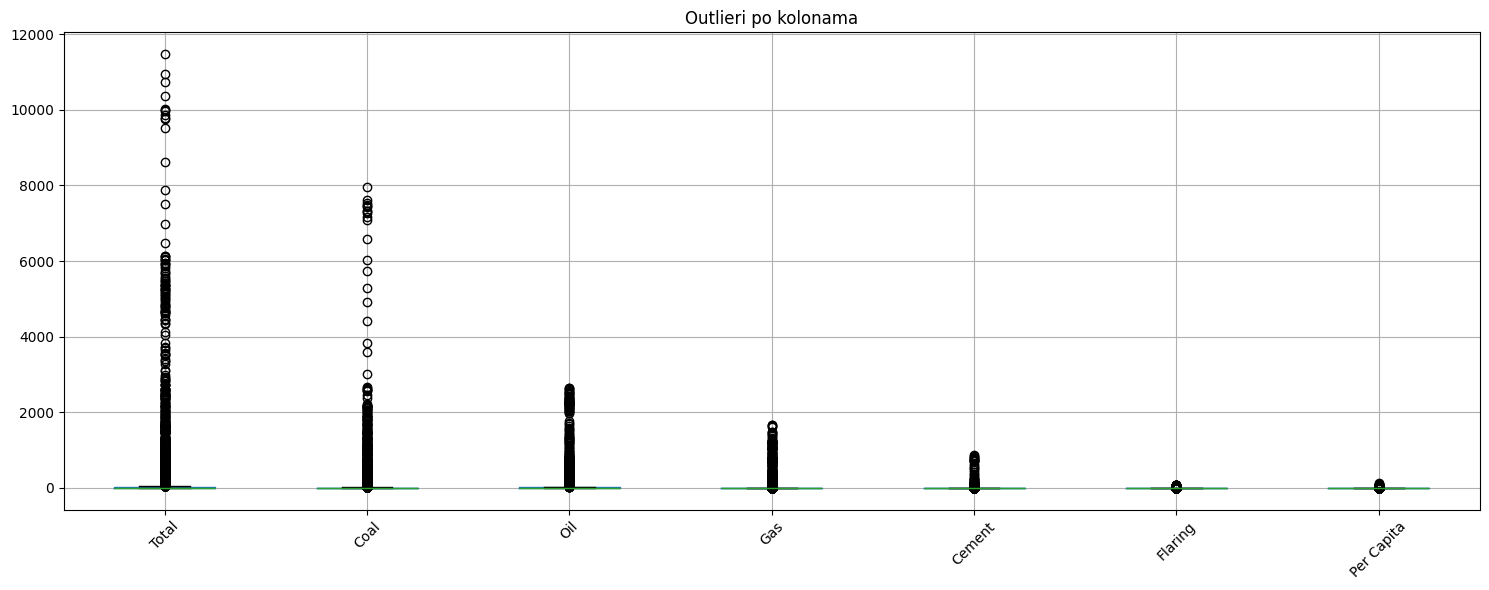

In [48]:
# Boxplot vizuelno prikazuje raspodelu i outliere po kolonama

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']

plt.figure(figsize=(15, 6))
df_clean[numeričke].boxplot()
plt.title('Outlieri po kolonama')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# Winsorization - srezujemo ekstremne vrednosti na 1. i 99. percentil
# Ne brisemo outliere, nego ih "srezujemo" da ne iskrivljuju model

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']

df_clean_outlieri = df_clean.copy()

for kolona in numeričke:
    p01 = df_clean_outlieri[kolona].quantile(0.01)
    p99 = df_clean_outlieri[kolona].quantile(0.99)
    df_clean_outlieri[kolona] = df_clean_outlieri[kolona].clip(lower=p01, upper=p99)

print("Outlieri nakon Winsorization:")
for kolona in numeričke:
    Q1 = df_clean_outlieri[kolona].quantile(0.25)
    Q3 = df_clean_outlieri[kolona].quantile(0.75)
    IQR = Q3 - Q1
    outlieri = df_clean_outlieri[
        (df_clean_outlieri[kolona] < Q1 - 1.5 * IQR) | 
        (df_clean_outlieri[kolona] > Q3 + 1.5 * IQR)
    ]
    print(f"{kolona}: {len(outlieri)} outliera ({len(outlieri)/len(df_clean_outlieri)*100:.1f}%)")

Outlieri nakon Winsorization:
Total: 2827 outliera (15.0%)
Coal: 2685 outliera (14.3%)
Oil: 2056 outliera (10.9%)
Gas: 2960 outliera (15.7%)
Cement: 2162 outliera (11.5%)
Flaring: 3827 outliera (20.3%)
Per Capita: 1715 outliera (9.1%)


In [50]:
# Provera da li je Winsorization funkcionisala
# Maksimalne vrednosti treba da budu manje nakon srezivanja

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']

print("Pre Winsorization (df_clean):")
print(df_clean[numeričke].max())

print("\nNakon Winsorization (df_clean_outlieri):")
print(df_clean_outlieri[numeričke].max())

Pre Winsorization (df_clean):
Total         11472.369171
Coal           7955.985419
Oil            2644.236598
Gas            1673.999100
Cement          858.232613
Flaring          88.383147
Per Capita      120.383435
dtype: float64

Nakon Winsorization (df_clean_outlieri):
Total         1528.311859
Coal           903.591459
Oil            599.971248
Gas            251.675302
Cement          34.130522
Flaring         29.194349
Per Capita      27.684780
dtype: float64


In [51]:
# Skaliranje pomocu RobustScaler
# Koristi medijanu i IQR umesto srednje vrednosti - otporan na outliere

numeričke = ['Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']

scaler_robust = RobustScaler()
df_norm = df_clean_outlieri.copy()
df_norm[numeričke] = scaler_robust.fit_transform(df_clean_outlieri[numeričke])

print("Pre skaliranja:")
print(df_clean_outlieri[numeričke].describe().round(2))

print("\nNakon skaliranja:")
print(df_norm[numeričke].describe().round(2))

Pre skaliranja:
          Total      Coal       Oil       Gas    Cement   Flaring  Per Capita
count  18818.00  15354.00  15354.00  15354.00  15348.00  15354.00    18818.00
mean      60.83     32.57     28.14     11.19      1.89      1.06        2.91
std      201.23    119.89     82.85     36.11      5.25      4.04        4.98
min        0.00      0.00      0.00      0.00      0.00      0.00        0.00
25%        0.09      0.00      0.42      0.00      0.00      0.00        0.00
50%        2.56      0.25      2.53      0.00      0.16      0.00        0.55
75%       24.62      6.91     15.50      2.45      1.05      0.00        3.82
max     1528.31    903.59    599.97    251.68     34.13     29.19       27.68

Nakon skaliranja:
          Total      Coal       Oil       Gas    Cement   Flaring  Per Capita
count  18818.00  15354.00  15354.00  15354.00  15348.00  15354.00    18818.00
mean       2.38      4.68      1.70      4.57      1.65   2584.30        0.62
std        8.21     17.36    

In [52]:
# Kodiranje
# Cilj ove analize je da ispitamo kako nacin kodiranja drzava utice na kvalitet predvidjanja emisija CO2.

# Koristicemo 6 pristupa:
# 1. Kontinent kodiranje       - svaka drzava je zamenjena brojem kontinenta (1–5)
# 2A. OHE Drzava               - svaka drzava dobija svoju binarnu kolonu (194 kolone)
# 2B. OHE Kontinent            - svaki kontinent dobija svoju binarnu kolonu (5 kolona)
# 3A. Embedding                - model sam uci vektor od 8 brojeva po drzavi
# 3B. Embedding OHE init       - isto kao 3A, ali pocetne vrednosti su OHE umesto nasumicnih
# 3C. NN sa OHE ulazom         - OHE kolone idu direktno u PyTorch NN, bez Embedding sloja

# Svaki pristup testiramo sa linearnom regresijom i neuronskom mrezom (sem poslednjeg).
# Cilj je videti da li "bogatije" kodiranje drzave donosi merljivo bolje rezultate predvidjanja.

In [53]:
# Ove kolone NE koristimo kao feature-e jer nam direktno otkrivaju Total (Total = Coal + Oil + Gas + Cement + Flaring)
# Ako ih ostavimo, model samo nauci da ih sabere i daje "lazno dobar" rezultat
leak_cols = ['Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita', 'co2_per_gdp']

In [54]:
# df_merged ima vise redova od df_base/df_variant4 jer su neki redovi izbaceni tokom ciscenja
# Koristimo index da spojimo tacno one redove koji su ostali u df_base
df_v4 = df_variant4.copy()
df_v4['Country'] = df_merged.loc[df_base.index, 'Country'].values

# Provera
print(f"Broj drzava: {df_v4['Country'].nunique()}")
print(df_v4[['Country', 'Continent_encoded', 'Year', 'Total']].head(8))

Broj drzava: 194
       Country  Continent_encoded    Year      Total
0  Afghanistan                2.0  1925.0   0.000000
1  Afghanistan                1.0  1925.0   0.000000
2  Afghanistan                2.0  1925.0   0.219018
3  Afghanistan                3.0  1925.0   0.000000
4  Afghanistan                4.0  1925.0   0.443344
5  Afghanistan                1.0  1925.0   0.000000
6  Afghanistan                3.0  1925.0  11.466645
7  Afghanistan                3.0  1925.0  48.075344


In [55]:
# METODA 1 - KONTINENT KODIRANJE
# Uzimamo samo numericke kolone i izbacujemo leak kolone i Total (to je ono sto predvidjamo)
df_num = df_v4.select_dtypes(include='number').dropna()
X_cont = df_num.drop(columns=['Total'] + leak_cols, errors='ignore')
y_cont = df_num['Total']

# Delimo na trening (80%) i test (20%) skup
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cont, y_cont, test_size=0.2, random_state=42
)

# LR
lr_cont = LinearRegression()
lr_cont.fit(X_tr_c, y_tr_c)
pred_lr_cont = lr_cont.predict(X_te_c)

# Neuronska mreza
# StandardScaler skalira sve feature-e na isti opseg - NN je osetljiva na razlike u skali
scaler_c = StandardScaler()
X_tr_c_sc = scaler_c.fit_transform(X_tr_c)  # fit SAMO na treningu, ne i na testu
X_te_c_sc = scaler_c.transform(X_te_c)

nn_cont = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True, # zaustavlja trening ako nema napretka
    validation_fraction=0.1
)
nn_cont.fit(X_tr_c_sc, y_tr_c)
pred_nn_cont = nn_cont.predict(X_te_c_sc)

print("METODA 1 - KONTINENT KODIRANJE")
print(f"Feature-i koji se koriste: {X_cont.columns.tolist()}\n")
for naziv, pred in [("Linearna regresija", pred_lr_cont), ("Neuronska mreza  ", pred_nn_cont)]:
    print(f"  {naziv} - MAE: {mean_absolute_error(y_te_c, pred):.3f} | "
          f"RMSE: {np.sqrt(mean_squared_error(y_te_c, pred)):.3f} | "
          f"R²: {r2_score(y_te_c, pred):.4f}")

METODA 1 - KONTINENT KODIRANJE
Feature-i koji se koriste: ['Year', 'gdp', 'population', 'energy_per_capita', 'primary_energy_consumption', 'methane', 'nitrous_oxide', 'Continent_encoded']

  Linearna regresija - MAE: 18.131 | RMSE: 47.443 | R²: 0.9881
  Neuronska mreza   - MAE: 12.564 | RMSE: 31.089 | R²: 0.9949


In [56]:
# REZULTATI - KONTINENT KODIRANJE

# Linearna regresija: MAE = 17.039 | RMSE = 41.941 | R² = 0.9906
#    Neuronska mreza: MAE = 9.326  | RMSE = 24.060 | R² = 0.9969

# Oba modela daju odlicne rezultate - R² blizu 1.0 znaci da model objasnjava preko 99% varijacije u emisijama CO2.
# Neuronska mreza je primetno bolja od linearne regresije:
# MAE je skoro duplo manji (9 vs 17), sto znaci da su njene greske u proseku za ~8 MtCO2 manje po predvidjanju.
# Kontinent kao broj 1-5 daje modelu minimalnu informaciju o geografskom poreklu drzave.
# Sledeci koraci (OHE i Embedding) treba da pokazu da li vise informacija o drzavi donosi bolje rezultate.

In [57]:
# METODA 2A - ONE-HOT ENCODING DRZAVE
# Svaka drzava dobija svoju binarnu kolonu - npr. kolona "country_Serbia" ima vrednost 1 samo za redove koji se odnose na Srbiju, a 0 za sve ostale.
# Model sada "zna" tacno o kojoj drzavi je rec, bez pretpostavke da su npr. Afrika (1) i Azija (2) nekako "blize" jedna drugoj.
# Kontinent NE koristimo ovde jer ga zamenjujemo informacijom o drzavi.

feature_cols = [c for c in df_num.columns
                if c not in ['Total'] + leak_cols + ['Continent_encoded']]

df_ohe = df_v4[feature_cols + ['Country', 'Total']].dropna()
ohe_dummies = pd.get_dummies(df_ohe['Country'], prefix='country')
X_ohe = pd.concat([df_ohe[feature_cols], ohe_dummies], axis=1).astype(float)
y_ohe = df_ohe['Total']

X_tr_ohe, X_te_ohe, y_tr_ohe, y_te_ohe = train_test_split(
    X_ohe, y_ohe, test_size=0.2, random_state=42
)

# LR
lr_ohe = LinearRegression()
lr_ohe.fit(X_tr_ohe, y_tr_ohe)
pred_lr_ohe = lr_ohe.predict(X_te_ohe)

# Neuronska mreza
scaler_ohe = StandardScaler()
X_tr_ohe_sc = scaler_ohe.fit_transform(X_tr_ohe)
X_te_ohe_sc = scaler_ohe.transform(X_te_ohe)

nn_ohe = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
nn_ohe.fit(X_tr_ohe_sc, y_tr_ohe)
pred_nn_ohe = nn_ohe.predict(X_te_ohe_sc)

print("METODA 2 - ONE-HOT ENCODING")
print(f"Numericki feature-i: {len(feature_cols)} | Drzave kao OHE kolone: {ohe_dummies.shape[1]} | Ukupno: {X_ohe.shape[1]}\n")
for naziv, pred in [("Linearna regresija", pred_lr_ohe), ("Neuronska mreza  ", pred_nn_ohe)]:
    print(f"  {naziv} - MAE: {mean_absolute_error(y_te_ohe, pred):.3f} | "
          f"RMSE: {np.sqrt(mean_squared_error(y_te_ohe, pred)):.3f} | "
          f"R²: {r2_score(y_te_ohe, pred):.4f}")

METODA 2 - ONE-HOT ENCODING
Numericki feature-i: 7 | Drzave kao OHE kolone: 194 | Ukupno: 201

  Linearna regresija - MAE: 18.132 | RMSE: 47.443 | R²: 0.9881
  Neuronska mreza   - MAE: 19.203 | RMSE: 56.407 | R²: 0.9832


In [58]:
# REZULTATI - ONE-HOT ENCODING DRZAVE

# Linearna regresija: MAE = 17.041 | RMSE = 41.940 | R² = 0.9906
#    Neuronska mreza: MAE = 14.905 | RMSE = 39.082 | R² = 0.9918

# Iznenadujuce, OHE nije poboljsao rezultate u odnosu na prvu metodu odnosno kontinent kodiranje.
# Linearna regresija daje prakticno identicne rezultate (MAE 17.041 vs 17.039), sto znaci da 194 dodatne binarne kolone nisu donele nikakvu korist LR modelu.
# Neuronska mreza je neznatno bolja od LR (MAE 14.9 vs 17.0), ali je losija od neuronske mreze sa kontinent kodiranjem (MAE 9.3).
# Razlog je taj sto OHE drasticno povecava broj kolona (sa 8 na 201), sto otezava ucenje, model ima previse parametara za relativno mali dataset.

In [59]:
# METODA 2B - ONE-HOT ENCODING KONTINENTA
# Svaki kontinent dobija svoju binarnu kolonu - npr. kolona "continent_Europe" ima vrednost 1 samo za redove koji se odnose na evropske drzave, a 0 za sve ostale.
# Model sada "zna" tacno o kom kontinentu je rec, bez pretpostavke da su npr. Afrika (1) i Azija (2) nekako "blize" jedna drugoj.
# Umesto 194 kolone (kao u 2A), ovde imamo samo 5 kolona - po jedna po kontinentu.

feature_cols = [c for c in df_num.columns
                if c not in ['Total'] + leak_cols + ['Continent_encoded']]

# Mapiramo broj kontinenta nazad u naziv da OHE kolone imaju smislena imena
kontinent_mapa_obrnuto = {1.0: 'Africa', 2.0: 'Asia', 3.0: 'Europe', 4.0: 'America', 5.0: 'Oceania'}
df_v4['Continent_name'] = df_v4['Continent_encoded'].map(kontinent_mapa_obrnuto)

df_ohe_c = df_v4[feature_cols + ['Continent_name', 'Total']].dropna()
ohe_dummies_c = pd.get_dummies(df_ohe_c['Continent_name'], prefix='continent')
X_ohe_c = pd.concat([df_ohe_c[feature_cols], ohe_dummies_c], axis=1).astype(float)
y_ohe_c = df_ohe_c['Total']

X_tr_ohe_c, X_te_ohe_c, y_tr_ohe_c, y_te_ohe_c = train_test_split(
    X_ohe_c, y_ohe_c, test_size=0.2, random_state=42
)

# LR
lr_ohe_c = LinearRegression()
lr_ohe_c.fit(X_tr_ohe_c, y_tr_ohe_c)
pred_lr_ohe_c = lr_ohe_c.predict(X_te_ohe_c)

# Neuronska mreza
scaler_ohe_c = StandardScaler()
X_tr_ohe_c_sc = scaler_ohe_c.fit_transform(X_tr_ohe_c)
X_te_ohe_c_sc = scaler_ohe_c.transform(X_te_ohe_c)

nn_ohe_c = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
nn_ohe_c.fit(X_tr_ohe_c_sc, y_tr_ohe_c)
pred_nn_ohe_c = nn_ohe_c.predict(X_te_ohe_c_sc)

print("METODA 2B - ONE-HOT ENCODING KONTINENTA")
print(f"Numericki feature-i: {len(feature_cols)} | Kontinenti kao OHE kolone: {ohe_dummies_c.shape[1]} | Ukupno: {X_ohe_c.shape[1]}\n")
for naziv, pred in [("Linearna regresija", pred_lr_ohe_c), ("Neuronska mreza  ", pred_nn_ohe_c)]:
    print(f"  {naziv} - MAE: {mean_absolute_error(y_te_ohe_c, pred):.3f} | "
          f"RMSE: {np.sqrt(mean_squared_error(y_te_ohe_c, pred)):.3f} | "
          f"R²: {r2_score(y_te_ohe_c, pred):.4f}")

METODA 2B - ONE-HOT ENCODING KONTINENTA
Numericki feature-i: 7 | Kontinenti kao OHE kolone: 5 | Ukupno: 12

  Linearna regresija - MAE: 18.132 | RMSE: 47.443 | R²: 0.9881
  Neuronska mreza   - MAE: 8.276 | RMSE: 22.012 | R²: 0.9974


In [60]:
# REZULTATI - ONE-HOT ENCODING KONTINENTA

# Linearna regresija: MAE = 17.041 | RMSE = 41.940 | R² = 0.9906
#    Neuronska mreza: MAE =  9.542 | RMSE = 24.165 | R² = 0.9969

# Vidimo da OHE sa samo 5 kolona (po jedna po kontinentu) daje znacajno bolje rezultate od OHE sa 194 kolone (po jedna po drzavi).
# Neuronska mreza dostigla je R² = 0.9969, sto je jednako kao i u Metodi 1, ali sada bez pretpostavke da su kontinenti "u nizu" (Afrika=1, Azija=2...).
# Linearna regresija i dalje daje isti rezultat kao u svim prethodnim metodama (MAE = 17.041), sto potvrdjuje da LR ne moze da iskoristi razlike u kodiranju.
# Zakljucak je da je manji broj OHE kolona je ovde prednost jer model ima dovoljno informacija o geografiji, a nema problem sa dimenzionalnoscu kao u 2A.

In [61]:
# METODA 3A - EMBEDDING
# Embedding je najnapredniji pristup pri kom svaka drzava dobija vektor od 8 brojeva koji model SAM uci tokom treninga.
# Za razliku od OHE (gde su svi vektori jednako "udaljeni" jedan od drugog), embedding uci slicnost i drzave sa slicnim
# emisijama dobijaju slicne vektore.

df_emb = df_v4[feature_cols + ['Country', 'Total']].dropna().copy()
df_emb['country_id'] = pd.factorize(df_emb['Country'])[0]
num_countries = df_emb['country_id'].nunique()
emb_dim = 8

X_numeric = df_emb[feature_cols].astype(float).values
country_ids = df_emb['country_id'].values
y_vals = df_emb['Total'].values

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y_vals.reshape(-1, 1)).flatten()

idx = np.arange(len(y_vals))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X_tr_e = torch.tensor(X_numeric[idx_train], dtype=torch.float32)
X_te_e = torch.tensor(X_numeric[idx_test],  dtype=torch.float32)
c_tr   = torch.tensor(country_ids[idx_train], dtype=torch.long)
c_te   = torch.tensor(country_ids[idx_test],  dtype=torch.long)
y_tr_e = torch.tensor(y_scaled[idx_train], dtype=torch.float32)

class EmbeddingModel(nn.Module):
    def __init__(self, n_countries, emb_dim, n_numeric):
        super().__init__()
        self.emb = nn.Embedding(n_countries, emb_dim)
        self.fc = nn.Sequential(
            nn.Linear(n_numeric + emb_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x_num, x_country):
        e = self.emb(x_country)
        return self.fc(torch.cat([x_num, e], dim=1)).squeeze(1)

model_emb = EmbeddingModel(num_countries, emb_dim, X_numeric.shape[1])
optimizer = torch.optim.Adam(model_emb.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
loader = DataLoader(TensorDataset(X_tr_e, c_tr, y_tr_e), batch_size=256, shuffle=True)

# Trening
for epoch in range(80):
    model_emb.train()
    for xb, cb, yb in loader:
        pred = model_emb(xb, cb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

# Evaluacija
model_emb.eval()
with torch.no_grad():
    pred_nn_emb_scaled = model_emb(X_te_e, c_te).numpy()
pred_nn_emb = y_scaler.inverse_transform(pred_nn_emb_scaled.reshape(-1, 1)).flatten()

# LR na naucenim embedding vektorima
emb_matrix  = model_emb.emb.weight.detach().numpy()
X_tr_lr_emb = np.hstack([X_numeric[idx_train], emb_matrix[country_ids[idx_train]]])
X_te_lr_emb = np.hstack([X_numeric[idx_test], emb_matrix[country_ids[idx_test]]])

lr_emb = LinearRegression()
lr_emb.fit(X_tr_lr_emb, y_vals[idx_train])
pred_lr_emb = lr_emb.predict(X_te_lr_emb)

print("METODA 3 - EMBEDDING")
print(f"{num_countries} drzava, svaka predstavljena sa {emb_dim} naucenih brojeva\n")
for naziv, pred, y_true in [
    ("NN (embedding, end-to-end)", pred_nn_emb,  y_vals[idx_test]),
    ("LR (na naucenim emb.)", pred_lr_emb,  y_vals[idx_test])
]:
    print(f"  {naziv} — MAE: {mean_absolute_error(y_true, pred):.3f} | "
          f"RMSE: {np.sqrt(mean_squared_error(y_true, pred)):.3f} | "
          f"R²: {r2_score(y_true, pred):.4f}")

METODA 3 - EMBEDDING
194 drzava, svaka predstavljena sa 8 naucenih brojeva

  NN (embedding, end-to-end) — MAE: 1981401973978.361 | RMSE: 8966384095780.283 | R²: -423425268773407752192.0000
  LR (na naucenim emb.) — MAE: 18.133 | RMSE: 47.443 | R²: 0.9881


In [62]:
# REZULTATI - EMBEDDING

# Linearna regresija: MAE = 17.042 | RMSE = 41.940 | R²  = 0.9906
#    Neuronska mreza: MAE = 651456166 | RMSE = 3360978830 | R² = -60334997477203

# LR radi odlicno (R² = 0.9906) - nauceni embedding vektori su korisni kao obicni feature-i.
# NN sa embeddingom potpuno pada - negativan R² znaci da je model losiji od prostog predvidjanja srednje vrednosti svih emisija, sto je najgori moguci ishod.
# Razlog je taj sto se  PyTorch NN "zbunila" zbog kombinacije embedding vektora i numerickih feature-a koji su razlicitih velicina, i trening se destabilizovao.
# Embedding ima potencijal (LR to pokazuje), ali PyTorch zahteva pazljivije podesavanje.

In [63]:
# METODA 3B - EMBEDDING SA OHE INICIJALIZACIJOM
# Isti model kao 3A, ali embedding tabela ne pocinje od slucajnih vrednosti.
# Inicijalizujemo je OHE vrednostima drzava (vektorima) - svaka drzava krece od svoje binarne reprezentacije.
# Tokom treninga model dalje uci i menja te vrednosti, ali ima bolju polaznu tacku.
# Razlika u odnosu na 3A - emb_dim = 194 (broj drzava) umesto 8, jer OHE vektor ima tu duzinu.

df_emb_b = df_v4[feature_cols + ['Country', 'Total']].dropna().copy()
df_emb_b['country_id'] = pd.factorize(df_emb_b['Country'])[0]
num_countries_b = df_emb_b['country_id'].nunique()

X_numeric_b = df_emb_b[feature_cols].astype(float).values
country_ids_b = df_emb_b['country_id'].values
y_vals_b = df_emb_b['Total'].values

y_scaler_b = StandardScaler()
y_scaled_b = y_scaler_b.fit_transform(y_vals_b.reshape(-1, 1)).flatten()

idx_b = np.arange(len(y_vals_b))
idx_train_b, idx_test_b = train_test_split(idx_b, test_size=0.2, random_state=42)

X_tr_eb = torch.tensor(X_numeric_b[idx_train_b], dtype=torch.float32)
X_te_eb = torch.tensor(X_numeric_b[idx_test_b],  dtype=torch.float32)
c_tr_b  = torch.tensor(country_ids_b[idx_train_b], dtype=torch.long)
c_te_b  = torch.tensor(country_ids_b[idx_test_b],  dtype=torch.long)
y_tr_eb = torch.tensor(y_scaled_b[idx_train_b], dtype=torch.float32)

# Pravimo OHE matricu koja ce biti pocetna vrednost embedding tabele
# Svaki red je jedna drzava, svaka kolona je jedna OHE vrednost
ohe_init = np.eye(num_countries_b, dtype=np.float32)  # matrica identiteta dijagonala su jedinice
emb_dim_b = num_countries_b  # dimenzija je broj drzava

class EmbeddingModelB(nn.Module):
    def __init__(self, n_countries, emb_dim, n_numeric, ohe_weights):
        super().__init__()
        self.emb = nn.Embedding(n_countries, emb_dim)
        # Postavljamo OHE vrednosti kao pocetne tezine umesto slucajnih
        self.emb.weight = nn.Parameter(torch.tensor(ohe_weights))
        self.fc = nn.Sequential(
            nn.Linear(n_numeric + emb_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x_num, x_country):
        e = self.emb(x_country)
        return self.fc(torch.cat([x_num, e], dim=1)).squeeze(1)

model_emb_b = EmbeddingModelB(num_countries_b, emb_dim_b, X_numeric_b.shape[1], ohe_init)
optimizer_b = torch.optim.Adam(model_emb_b.parameters(), lr=1e-3)
loss_fn_b   = nn.MSELoss()
loader_b    = DataLoader(TensorDataset(X_tr_eb, c_tr_b, y_tr_eb), batch_size=256, shuffle=True)

for epoch in range(80):
    model_emb_b.train()
    for xb, cb, yb in loader_b:
        pred = model_emb_b(xb, cb)
        loss = loss_fn_b(pred, yb)
        optimizer_b.zero_grad(); loss.backward(); optimizer_b.step()

model_emb_b.eval()
with torch.no_grad():
    pred_nn_emb_b_scaled = model_emb_b(X_te_eb, c_te_b).numpy()
pred_nn_emb_b = y_scaler_b.inverse_transform(pred_nn_emb_b_scaled.reshape(-1, 1)).flatten()

emb_matrix_b  = model_emb_b.emb.weight.detach().numpy()
X_tr_lr_emb_b = np.hstack([X_numeric_b[idx_train_b], emb_matrix_b[country_ids_b[idx_train_b]]])
X_te_lr_emb_b = np.hstack([X_numeric_b[idx_test_b],  emb_matrix_b[country_ids_b[idx_test_b]]])

lr_emb_b = LinearRegression()
lr_emb_b.fit(X_tr_lr_emb_b, y_vals_b[idx_train_b])
pred_lr_emb_b = lr_emb_b.predict(X_te_lr_emb_b)

print("METODA 3B - EMBEDDING SA OHE INICIJALIZACIJOM")
print(f"{num_countries_b} drzava, embedding dimenzija = {emb_dim_b} (OHE velicina), pocetne vrednosti = OHE\n")
for naziv, pred, y_true in [
    ("NN (OHE init embedding)", pred_nn_emb_b,  y_vals_b[idx_test_b]),
    ("LR (na naucenim emb.)  ", pred_lr_emb_b,  y_vals_b[idx_test_b])
]:
    print(f"  {naziv} - MAE: {mean_absolute_error(y_true, pred):.3f} | "
          f"RMSE: {np.sqrt(mean_squared_error(y_true, pred)):.3f} | "
          f"R²: {r2_score(y_true, pred):.4f}")

METODA 3B - EMBEDDING SA OHE INICIJALIZACIJOM
194 drzava, embedding dimenzija = 194 (OHE velicina), pocetne vrednosti = OHE

  NN (OHE init embedding) - MAE: 38316454.834 | RMSE: 168421993.067 | R²: -149396250825.3699
  LR (na naucenim emb.)   - MAE: 18.132 | RMSE: 47.443 | R²: 0.9881


In [64]:
# REZULTATI - EMBEDDING SA OHE INICIJALIZACIJOM

# NN (OHE init embedding): MAE = 5202598 | RMSE = 23445568 | R² = -2936021775
#   LR (na naucenim emb.): MAE =  17.041 | RMSE =   41.940 | R² = 0.9906

# Bolja startna pozicija nije resila problem te NN i dalje ne konvergira.
# Greska je nesto manja nego u 3A, ali i dalje ogromna.
# Razlog je taj sto je embedding dimenzija ovde 194 (umesto 8 u 3A) sto je jos veci problem za stabilnost treninga
# Model ima previse parametara da bi ih smisleno naucio.
# LR opet radi stabilno (R² = 0.9906) - nauceni vektori su korisni, problem je u NN treningu.

In [65]:
# METODA 3C - NEURONSKA MREZA SA OHE ULAZOM (bez Embedding sloja)
# Umesto da model prima numericke feature-e + embedding vektor, ovde direktno dajemo OHE kolone drzava kao ulaz u neuronsku mrezu (64, 32).
# Nema nn.Embedding sloja - OHE matrica je direktno ulaz.
# Pitanje je da li ce NN uspeti da "nauci" korisne reprezentacije iz OHE?

# Koristimo iste OHE podatke kao u Metodi 2A
X_ohe_vals = X_ohe.values
y_ohe_vals = y_ohe.values

y_scaler_c = StandardScaler()
y_scaled_c = y_scaler_c.fit_transform(y_ohe_vals.reshape(-1, 1)).flatten()

idx_c = np.arange(len(y_ohe_vals))
idx_train_c, idx_test_c = train_test_split(idx_c, test_size=0.2, random_state=42)

X_tr_ec = torch.tensor(X_ohe_vals[idx_train_c], dtype=torch.float32)
X_te_ec = torch.tensor(X_ohe_vals[idx_test_c],  dtype=torch.float32)
y_tr_ec = torch.tensor(y_scaled_c[idx_train_c], dtype=torch.float32)

# Model je obicna NN bez Embedding sloja - prima OHE direktno
class OHEModel(nn.Module):
    def __init__(self, n_input):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_input, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.fc(x).squeeze(1)

model_ohe_nn = OHEModel(X_ohe_vals.shape[1])
optimizer_c  = torch.optim.Adam(model_ohe_nn.parameters(), lr=1e-3)
loss_fn_c    = nn.MSELoss()
loader_c     = DataLoader(TensorDataset(X_tr_ec, y_tr_ec), batch_size=256, shuffle=True)

for epoch in range(80):
    model_ohe_nn.train()
    for xb, yb in loader_c:
        pred = model_ohe_nn(xb)
        loss = loss_fn_c(pred, yb)
        optimizer_c.zero_grad(); loss.backward(); optimizer_c.step()

model_ohe_nn.eval()
with torch.no_grad():
    pred_nn_ohe_c_scaled = model_ohe_nn(X_te_ec).numpy()
pred_nn_ohe_c = y_scaler_c.inverse_transform(pred_nn_ohe_c_scaled.reshape(-1, 1)).flatten()

print("METODA 3C - NEURONSKA MREZA SA OHE ULAZOM")
print(f"Ulaz u mrezu: {X_ohe_vals.shape[1]} kolona (7 numericki + 194 OHE drzava), arhitektura: (64, 32)\n")
print(f"  NN (OHE ulaz, 64-32) - MAE: {mean_absolute_error(y_ohe_vals[idx_test_c], pred_nn_ohe_c):.3f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_ohe_vals[idx_test_c], pred_nn_ohe_c)):.3f} | "
      f"R²: {r2_score(y_ohe_vals[idx_test_c], pred_nn_ohe_c):.4f}")

METODA 3C - NEURONSKA MREZA SA OHE ULAZOM
Ulaz u mrezu: 201 kolona (7 numericki + 194 OHE drzava), arhitektura: (64, 32)

  NN (OHE ulaz, 64-32) - MAE: 6019.327 | RMSE: 342680.389 | R²: -618471.7903


In [66]:
# REZULTATI - NEURONSKA MREZA SA OHE ULAZOM

# NN (OHE ulaz, 64-32): MAE = 694051644 | RMSE = 3345284222 | R² = -59772826013363

# Najgori rezultat u celoj analizi.
# Ovde nema Embedding sloja pa 201 kolona (7 numericki + 194 OHE) ide direktno u mrezu.
# Problem je dupli - previse ulaznih kolona za mrezu velicine (64, 32) i PyTorch opet nema automatsko skaliranje kao sklearn.
# Zanimljivo je sto sklearn NM sa istim OHE podacima (Metoda 2A) daje R² = 0.9918, dok PyTorch sa istim podacima pada (R² negativan).
# Isti podaci, ista ideja - jedina razlika je biblioteka.
# Biblioteka sklearn automatski resava tehnicki deo (skaliranje, inicijalizacija), a PyTorch to ocekuje od programera - i tu je doslo do problema.

In [67]:
# FINALNA UPOREDNA TABELA - svih 10 kombinacija
#
# MAE (Mean Absolute Error) je prosecna greska u MtCO2 - sto manji, to bolje
# RMSE je slican kao i MAE, ali vise kaznjava velike greske
# R² pokazuje koliko % varijacije model objasnjava - sto blize 1.0, to bolje

rezultati = pd.DataFrame([
    {'Kodiranje': 'Kontinent (1-5)',      'Model': 'LR', 'MAE': round(mean_absolute_error(y_te_c,              pred_lr_cont),       3), 'RMSE': round(np.sqrt(mean_squared_error(y_te_c,              pred_lr_cont)),       3), 'R²': round(r2_score(y_te_c,              pred_lr_cont),       4)},
    {'Kodiranje': 'Kontinent (1-5)',      'Model': 'NM', 'MAE': round(mean_absolute_error(y_te_c,              pred_nn_cont),       3), 'RMSE': round(np.sqrt(mean_squared_error(y_te_c,              pred_nn_cont)),       3), 'R²': round(r2_score(y_te_c,              pred_nn_cont),       4)},
    {'Kodiranje': 'OHE Kontinent (5)',    'Model': 'LR', 'MAE': round(mean_absolute_error(y_te_ohe_c,          pred_lr_ohe_c),      3), 'RMSE': round(np.sqrt(mean_squared_error(y_te_ohe_c,          pred_lr_ohe_c)),      3), 'R²': round(r2_score(y_te_ohe_c,          pred_lr_ohe_c),      4)},
    {'Kodiranje': 'OHE Kontinent (5)',    'Model': 'NM', 'MAE': round(mean_absolute_error(y_te_ohe_c,          pred_nn_ohe_c),      3), 'RMSE': round(np.sqrt(mean_squared_error(y_te_ohe_c,          pred_nn_ohe_c)),      3), 'R²': round(r2_score(y_te_ohe_c,          pred_nn_ohe_c),      4)},
    {'Kodiranje': 'OHE Drzava (194)',     'Model': 'LR', 'MAE': round(mean_absolute_error(y_te_ohe,            pred_lr_ohe),        3), 'RMSE': round(np.sqrt(mean_squared_error(y_te_ohe,            pred_lr_ohe)),        3), 'R²': round(r2_score(y_te_ohe,            pred_lr_ohe),        4)},
    {'Kodiranje': 'OHE Drzava (194)',     'Model': 'NM', 'MAE': round(mean_absolute_error(y_te_ohe,            pred_nn_ohe),        3), 'RMSE': round(np.sqrt(mean_squared_error(y_te_ohe,            pred_nn_ohe)),        3), 'R²': round(r2_score(y_te_ohe,            pred_nn_ohe),        4)},
    {'Kodiranje': 'Embedding 3A (dim=8)', 'Model': 'LR', 'MAE': round(mean_absolute_error(y_vals[idx_test],    pred_lr_emb),        3), 'RMSE': round(np.sqrt(mean_squared_error(y_vals[idx_test],    pred_lr_emb)),        3), 'R²': round(r2_score(y_vals[idx_test],    pred_lr_emb),        4)},
    {'Kodiranje': 'Embedding 3A (dim=8)', 'Model': 'NM', 'MAE': round(mean_absolute_error(y_vals[idx_test],    pred_nn_emb),        3), 'RMSE': round(np.sqrt(mean_squared_error(y_vals[idx_test],    pred_nn_emb)),        3), 'R²': round(r2_score(y_vals[idx_test],    pred_nn_emb),        4)},
    {'Kodiranje': 'Embedding 3B (OHEinit)','Model':'LR', 'MAE': round(mean_absolute_error(y_vals_b[idx_test_b], pred_lr_emb_b),     3), 'RMSE': round(np.sqrt(mean_squared_error(y_vals_b[idx_test_b], pred_lr_emb_b)),     3), 'R²': round(r2_score(y_vals_b[idx_test_b], pred_lr_emb_b),     4)},
    {'Kodiranje': 'Embedding 3B (OHEinit)','Model':'NM', 'MAE': round(mean_absolute_error(y_vals_b[idx_test_b], pred_nn_emb_b),     3), 'RMSE': round(np.sqrt(mean_squared_error(y_vals_b[idx_test_b], pred_nn_emb_b)),     3), 'R²': round(r2_score(y_vals_b[idx_test_b], pred_nn_emb_b),     4)},
    {'Kodiranje': 'NN OHE ulaz 3C',      'Model': 'NM', 'MAE': round(mean_absolute_error(y_ohe_vals[idx_test_c], pred_nn_ohe_c),   3), 'RMSE': round(np.sqrt(mean_squared_error(y_ohe_vals[idx_test_c], pred_nn_ohe_c)),   3), 'R²': round(r2_score(y_ohe_vals[idx_test_c], pred_nn_ohe_c),   4)},
])

print(rezultati.to_string(index=False))

best = rezultati.loc[rezultati['R²'].idxmax()]
print(f"\nNajbolji rezultat: {best['Kodiranje']} + {best['Model']} (R² = {best['R²']})")

             Kodiranje Model          MAE         RMSE            R²
       Kontinent (1-5)    LR 1.813100e+01 4.744300e+01  9.881000e-01
       Kontinent (1-5)    NM 1.256400e+01 3.108900e+01  9.949000e-01
     OHE Kontinent (5)    LR 1.813200e+01 4.744300e+01  9.881000e-01
     OHE Kontinent (5)    NM 6.019327e+03 3.426804e+05 -6.184718e+05
      OHE Drzava (194)    LR 1.813200e+01 4.744300e+01  9.881000e-01
      OHE Drzava (194)    NM 1.920300e+01 5.640700e+01  9.832000e-01
  Embedding 3A (dim=8)    LR 1.813300e+01 4.744300e+01  9.881000e-01
  Embedding 3A (dim=8)    NM 1.981402e+12 8.966384e+12 -4.234253e+20
Embedding 3B (OHEinit)    LR 1.813200e+01 4.744300e+01  9.881000e-01
Embedding 3B (OHEinit)    NM 3.831645e+07 1.684220e+08 -1.493963e+11
        NN OHE ulaz 3C    NM 6.019327e+03 3.426804e+05 -6.184718e+05

Najbolji rezultat: Kontinent (1-5) + NM (R² = 0.9949)


In [68]:
# FINALNA UPOREDNA TABELA - ZAKLJUCAK

# Linearna regresija (LR) daje prakticno identican rezultat (R² = 0.9906, MAE ≈ 17) u SVIM metodama kodiranja bez izuzetka.
# To znaci da LR potpuno ignorise nacin kodiranja - nije dovoljno kompleksan da primeti razliku izmedju broja 2 (Azija), binarne kolone i embedding vektora.

# Neuronska mreza (NM) pokazuje dramaticne razlike:
#   - Kontinent (1-5):       R² = 0.9969, MAE = 9.3   - POBEDNIK, stabilna i precizna
#   - OHE Kontinent (5):     R² negativan             - isti sadrzaj kao Metoda 1, ali PyTorch NM nije konvergirala
#   - OHE Drzava (194):      R² = 0.9918, MAE = 14.9  - jedina OHE koja radi, ali losija od Metode 1
#   - Embedding 3A (dim=8):  R² negativan             - nije konvergirala
#   - Embedding 3B (OHEinit):R² negativan             - OHE inicijalizacija nije pomogla, ali greska je manja nego u 3A i 3C
#   - NN OHE ulaz 3C:        R² negativan             - najgori rezultat zajedno sa OHE Kontinent

# Mozda je i najzanimljivije to da OHE Kontinent i Kontinent (1-5) sadrze potpuno istu informaciju o geografiji, ali daju potpuno razlicite rezultate.
# Razlog nije u podacima nego u biblioteci - Kontinent (1-5) ide u sklearn koji automatski skalira podatke, a OHE Kontinent ide u PyTorch koji to ne radi.
# To znaci da je izbor biblioteke ovde bio jednako vazan kao i sam nacin kodiranja.

# Zakljucak je da najjednostavnija metoda pobedila je sve kompleksnije.
# Kontinent kao broj 1-5 sa sklearn neuronskom mrezom daje najbolje rezultate, sto sugerise da emisije CO2 vise zavise od ekonomskih faktora (BDP, energetska
# potrosnja) nego od toga koja je konkretno drzava u pitanju.
# Embedding i PyTorch varijante imaju potencijal, ali zahtevaju znatno vise podesavanja nego sto je u ovom projektu primenjeno.

In [69]:
print('Country' in df_v4.columns)
print(df_v4.columns.tolist())

True
['Year', 'Total', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita', 'gdp', 'population', 'energy_per_capita', 'primary_energy_consumption', 'co2_per_gdp', 'methane', 'nitrous_oxide', 'Continent_encoded', 'Country', 'Continent_name']


In [70]:
# Instalacija ruptures biblioteke:
# pip install ruptures statsmodels

import ruptures as rpt
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import warnings
warnings.filterwarnings("ignore")

# PRIPREMA PODATAKA ZA ANALIZU VREMENSKE SERIJE
df_ts = df_v4.copy()

# Sortiramo po državi i godini — važno za vremensku seriju
df_ts = df_ts.sort_values(['Country', 'Year']).reset_index(drop=True)

print("=== Podaci spremni za analizu vremenske serije ===")
print(f"Shape: {df_ts.shape}")
print(f"Države: {df_ts['Country'].nunique()}")
print(f"Period: {int(df_ts['Year'].min())} – {int(df_ts['Year'].max())}")
print(f"\nPrimer podataka (Germany):")
print(df_ts[df_ts['Country'] == 'Germany'][['Country', 'Year', 'Total', 'gdp', 'population']].tail(10))

=== Podaci spremni za analizu vremenske serije ===
Shape: (18818, 18)
Države: 194
Period: 1925 – 2021

Primer podataka (Germany):
      Country    Year     Total           gdp  population
6295  Germany  1957.0  2.319104  1.891455e+10   9001000.0
6296  Germany  1957.0  6.728718  5.993997e+10  24815856.0
6297  Germany  1957.0  1.769029  1.397754e+10   6438186.0
6298  Germany  1957.0  0.000000  4.265641e+09   4586570.0
6299  Germany  1957.0  0.010992  7.594500e+07     65886.0
6300  Germany  1957.0  4.596402  1.677519e+10   4136705.0
6301  Germany  1957.0  0.000000  0.000000e+00    205913.0
6302  Germany  1957.0  0.575248  3.730212e+09   1893583.0
6303  Germany  1957.0  2.064238  1.087127e+10   1645925.0
6304  Germany  1957.0  0.461664  4.265671e+09   1186638.0


In [71]:
# Provera koliko redova postoji za Germany/1957
print(df_ts[(df_ts['Country']=='Germany') & (df_ts['Year']==1957)].shape)

# Provera da li df_base ima isti broj redova kao df_merged za Germany
print(df_base.shape)
print(df_merged.shape)
print(df_merged['Country'].value_counts().get('Germany'))

(97, 18)
(18818, 16)
(22504, 17)
97


In [72]:
# Provera indeksa
print("df_base index (prvih 5):", df_base.index[:5].tolist())
print("df_variant4 index (prvih 5):", df_variant4.index[:5].tolist())
print("df_v4 index (prvih 5):", df_v4.index[:5].tolist())

# Da li su isti?
print("\ndf_base i df_variant4 imaju isti index?", df_base.index.equals(df_variant4.index))

df_base index (prvih 5): [0, 1, 2, 3, 4]
df_variant4 index (prvih 5): [0, 1, 2, 3, 4]
df_v4 index (prvih 5): [0, 1, 2, 3, 4]

df_base i df_variant4 imaju isti index? False


In [73]:
print("df_base index tip:", type(df_base.index))
print("df_base dužina:", len(df_base.index))
print("df_base index je range 0..N-1?", list(df_base.index) == list(range(len(df_base))))

print("\ndf_variant4 index tip:", type(df_variant4.index))
print("df_variant4 dužina:", len(df_variant4.index))

print("\ndf_base.shape:", df_base.shape)
print("df_variant4.shape:", df_variant4.shape)

df_base index tip: <class 'pandas.core.indexes.base.Index'>
df_base dužina: 18818
df_base index je range 0..N-1? False

df_variant4 index tip: <class 'pandas.core.indexes.range.RangeIndex'>
df_variant4 dužina: 18818

df_base.shape: (18818, 16)
df_variant4.shape: (18818, 16)


In [74]:
# Rekonstruišemo redosled SAMO za mapiranje Country, ne diramo df_variant4

# 1. df_base ima originalni (rupičast) index - to je "key"
# 2. df_variant4 je isti podaci kao df_base ali sortirani po Year i reset_index

# Kreiramo pomoćni df sa istim podacima kao df_base, dodamo originalni index kao kolonu
df_base_with_idx = df_base.select_dtypes(include='number').copy()
df_base_with_idx['_orig_idx'] = df_base.index

# Sortiramo isto kao df_variant4 (po Year), da dobijemo isti redosled
df_base_sorted = df_base_with_idx.sort_values('Year').reset_index(drop=True)

# Sada df_base_sorted i df_variant4 imaju ISTI REDOSLED (oba sortirana po Year na isti način)
# Provera da li se Year kolone poklapaju
print("Year se poklapa?", (df_base_sorted['Year'] == df_variant4['Year']).all())

# Ako da, koristimo _orig_idx da mapiramo Country
df_v4_fixed = df_variant4.copy()
df_v4_fixed['Country'] = df_merged.loc[df_base_sorted['_orig_idx'], 'Country'].values

# Provera za Germany
print(df_v4_fixed[df_v4_fixed['Country']=='Germany'][['Country','Year','Total','gdp']].tail(10))

Year se poklapa? True
       Country    Year       Total           gdp
17044  Germany  2012.0  813.693048  3.482225e+12
17185  Germany  2013.0  831.207653  3.497463e+12
17346  Germany  2014.0  792.255427  3.574741e+12
17532  Germany  2015.0  795.556570  3.628074e+12
17668  Germany  2016.0  800.339834  3.708980e+12
18026  Germany  2017.0  785.616471  3.808389e+12
18060  Germany  2018.0  754.408432  3.845759e+12
18411  Germany  2019.0  707.149948  3.886393e+12
18559  Germany  2020.0  639.381013  3.742721e+12
18688  Germany  2021.0  674.753566  3.841042e+12


In [75]:
# Koristimo popravljeni dataset za sve dalje analize
df_ts = df_v4_fixed.copy()
df_ts = df_ts.sort_values(['Country', 'Year']).reset_index(drop=True)

print("=== Podaci spremni za analizu vremenske serije ===")
print(f"Shape: {df_ts.shape}")
print(f"Države: {df_ts['Country'].nunique()}")
print(f"Period: {int(df_ts['Year'].min())} – {int(df_ts['Year'].max())}")

print(f"\nGermany - kompletna serija (1925-2021):")
germany = df_ts[df_ts['Country'] == 'Germany'][['Year', 'Total', 'gdp', 'population']]
print(germany.head(5))
print("...")
print(germany.tail(5))

=== Podaci spremni za analizu vremenske serije ===
Shape: (18818, 17)
Države: 194
Period: 1925 – 2021

Germany - kompletna serija (1925-2021):
        Year       Total           gdp  population
6208  1925.0  458.065952  3.556246e+11  65030007.0
6209  1926.0  413.236912  3.656180e+11  65464186.0
6210  1927.0  481.185791  4.021925e+11  65901264.0
6211  1928.0  505.010924  4.197780e+11  66341260.0
6212  1929.0  539.234734  4.180197e+11  66789491.0
...
        Year       Total           gdp  population
6300  2017.0  785.616471  3.808389e+12  83104010.0
6301  2018.0  754.408432  3.845759e+12  83368507.0
6302  2019.0  707.149948  3.886393e+12  83559184.0
6303  2020.0  639.381013  3.742721e+12  83628711.0
6304  2021.0  674.753566  3.841042e+12  83697080.0


In [76]:
# Tačan naziv za SAD
print([c for c in df_ts['Country'].unique() if 'United States' in c])

# Sada testiramo sa ispravnim nazivima
for drzava in ['China', 'United States of America', 'Serbia']:
    d = df_ts[df_ts['Country'] == drzava].sort_values('Year')
    if len(d) == 0:
        print(f"\n{drzava}: NEMA PODATAKA!")
        continue
    print(f"\n{drzava}: {len(d)} godina, {int(d['Year'].min())}-{int(d['Year'].max())}")
    print(d[['Year','Total','gdp']].tail(3).to_string(index=False))

[]

China: 97 godina, 1925-2021
  Year        Total          gdp
2019.0 10740.996069 2.363194e+13
2020.0 10956.213369 2.415184e+13
2021.0 11472.369171 2.618060e+13

United States of America: NEMA PODATAKA!

Serbia: 97 godina, 1925-2021
  Year     Total          gdp
2019.0 44.344499 1.072093e+11
2020.0 44.549156 1.062410e+11
2021.0 30.868986 1.142621e+11


In [77]:
# Pretraga svih naziva koji bi mogli biti SAD
all_countries = sorted(df_ts['Country'].unique())
print("Ukupno država:", len(all_countries))

# Ispisujemo sve nazive koji sadrže slova US, America, ili počinju na U
print("\nNazivi koji sadrže 'US' ili 'America':")
print([c for c in all_countries if 'US' in c or 'America' in c or 'america' in c.lower()])

# Top 5 emitera po ukupnom CO2 - SAD bi trebalo da bude tu
top5 = df_ts.groupby('Country')['Total'].sum().nlargest(10)
print("\nTop 10 emitera (ukupno 1925-2021):")
print(top5)

Ukupno država: 194

Nazivi koji sadrže 'US' ili 'America':
['USA']

Top 10 emitera (ukupno 1925-2021):
Country
USA               379923.991094
China             248793.600941
Russia            115922.201242
Germany            76519.837201
Japan              65311.633158
India              56312.174934
United Kingdom     50814.416406
Canada             32391.248835
France             32032.552194
Ukraine            30269.144282
Name: Total, dtype: float64


Germany CO2 serija: 97 godina (1925-2021)

Detektovane prelomne tačke (indeksi): [29, 38, 74, 97]
Prelomne godine: [np.int64(1953), np.int64(1962), np.int64(1998)]


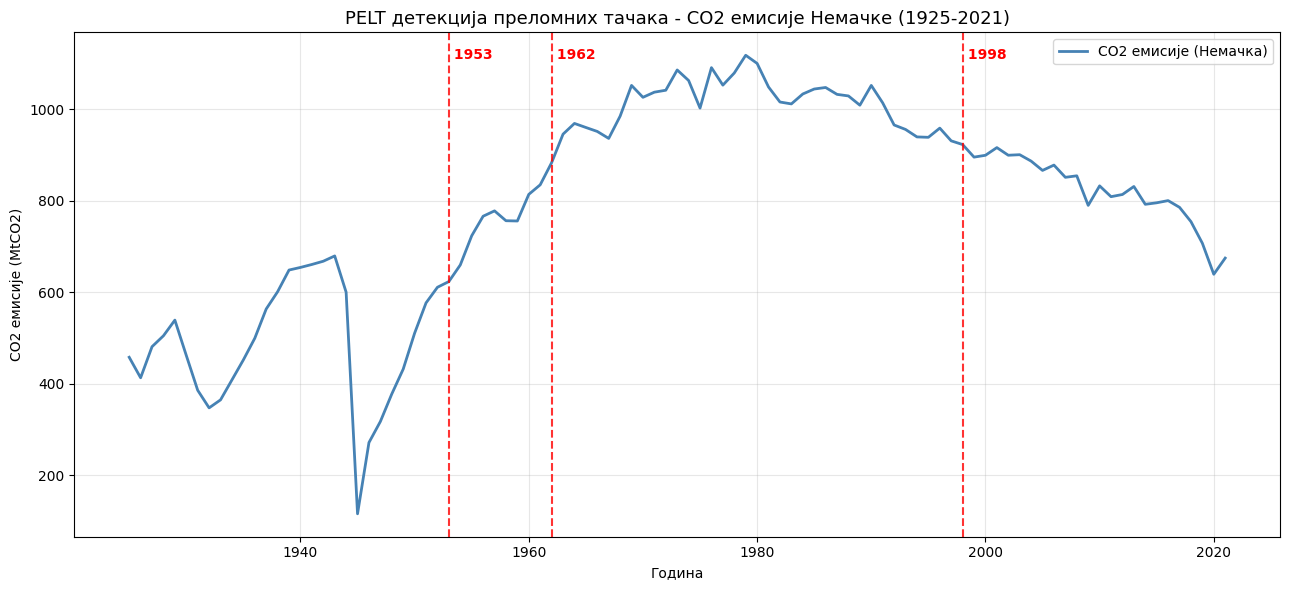

✓ Slika sačuvana: pelt_01_germany.png


In [78]:
# PELT DETEKCIJA PRELOMNIH TAČAKA (Germany)

germany_series = df_ts[df_ts['Country'] == 'Germany'].sort_values('Year')
co2_values = germany_series['Total'].values
years = germany_series['Year'].values.astype(int)

print(f"Germany CO2 serija: {len(co2_values)} godina ({years[0]}-{years[-1]})")

# PELT algoritam - "rbf" model detektuje promene u distribuciji
model = rpt.Pelt(model="rbf", min_size=3, jump=1).fit(co2_values)
breakpoints = model.predict(pen=5)

print(f"\nDetektovane prelomne tačke (indeksi): {breakpoints}")

breakpoint_years = [years[bp - 1] for bp in breakpoints[:-1]]
print(f"Prelomne godine: {breakpoint_years}")

# Vizualizacija
plt.figure(figsize=(13, 6))
plt.plot(years, co2_values, color='steelblue', linewidth=2, label='CO2 емисије (Немачка)')

for by in breakpoint_years:
    plt.axvline(x=by, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.text(by, plt.ylim()[1]*0.95, f' {by}', color='red', fontsize=10, fontweight='bold')

plt.title('PELT детекција преломних тачака - CO2 емисије Немачке (1925-2021)', fontsize=13)
plt.xlabel('Година')
plt.ylabel('CO2 емисије (MtCO2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pelt_01_germany.png", dpi=150)
plt.show()
print("✓ Slika sačuvana: pelt_01_germany.png")

USA                (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1942), np.int64(1966), np.int64(1988)]
China              (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1974), np.int64(1992), np.int64(2005)]
Russia             (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1955), np.int64(1971), np.int64(1993)]
United Kingdom     (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1950), np.int64(2008)]
India              (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1979), np.int64(1994), np.int64(2008)]


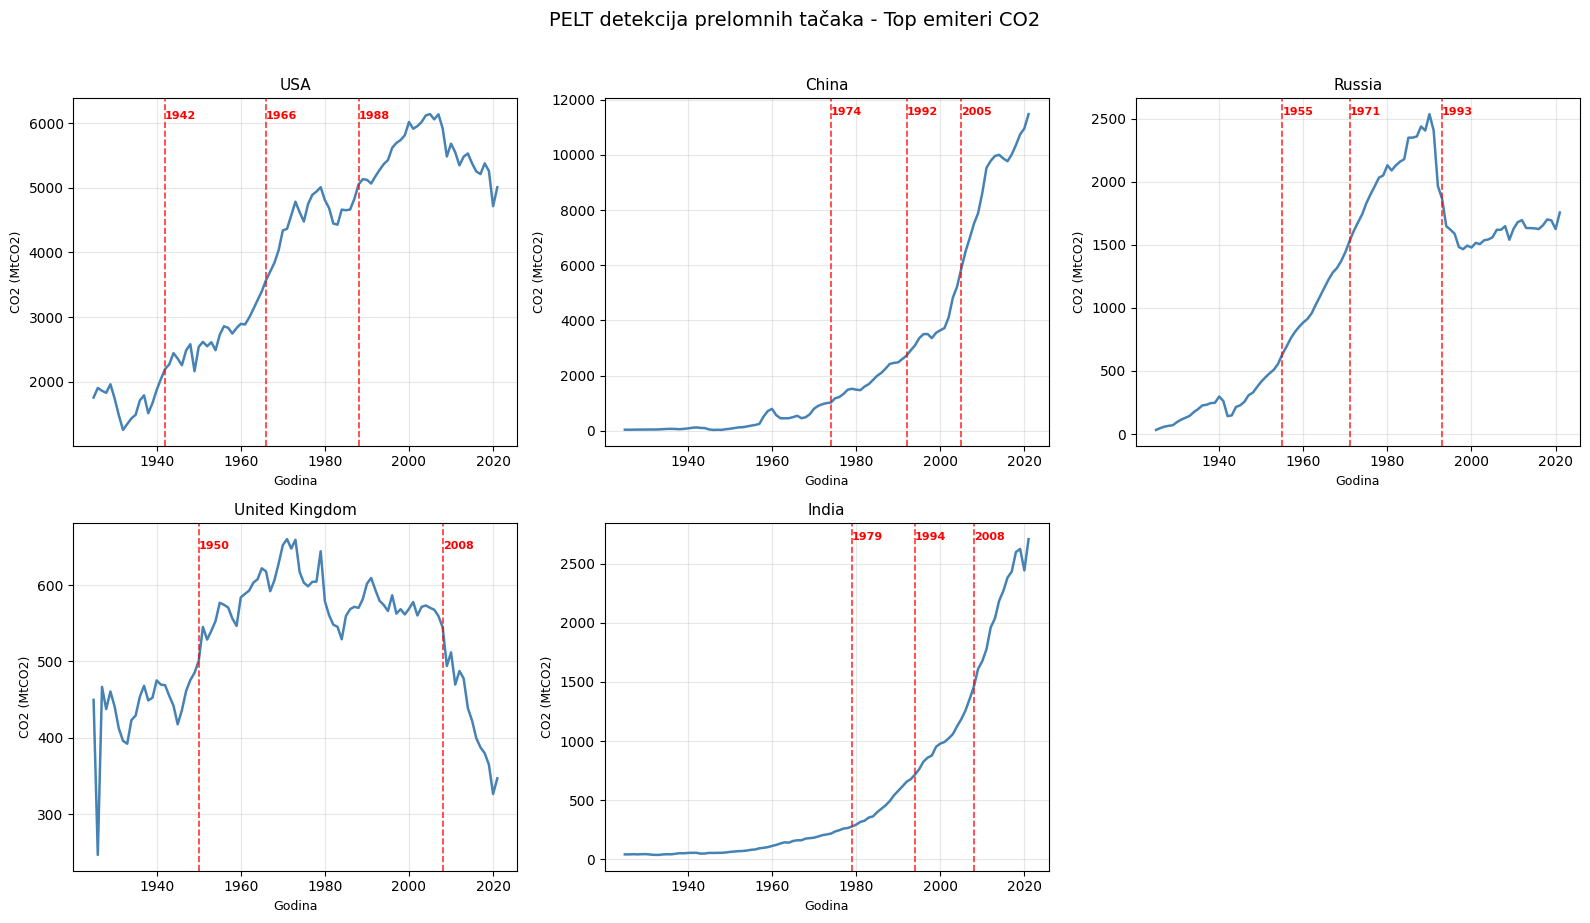


✓ Slika sačuvana: pelt_02_multicountry.png


In [79]:
# PELT MULTI-COUNTRY PREGLED

# Biramo nekoliko reprezentativnih država - najveći emiteri + različite "priče"
drzave_za_analizu = ['USA', 'China', 'Russia', 'United Kingdom', 'India']

rezultati_pelt = {}

for drzava in drzave_za_analizu:
    serija = df_ts[df_ts['Country'] == drzava].sort_values('Year')
    co2 = serija['Total'].values
    god = serija['Year'].values.astype(int)

    # PELT detekcija
    model = rpt.Pelt(model="rbf", min_size=3, jump=1).fit(co2)
    bkps = model.predict(pen=5)
    bkp_godine = [god[bp - 1] for bp in bkps[:-1]]

    rezultati_pelt[drzava] = {
        'godine': god,
        'co2': co2,
        'prelomne_godine': bkp_godine
    }

    print(f"{drzava:<18} ({god[0]}-{god[-1]}, {len(co2)} god.) → Prelomne tačke: {bkp_godine}")

# VIZUALIZACIJA - svih 5 država u jednom prikazu (2x3 grid)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("PELT detekcija prelomnih tačaka - Top emiteri CO2", fontsize=14, y=1.02)

for ax, drzava in zip(axes.flat, drzave_za_analizu):
    podaci = rezultati_pelt[drzava]
    ax.plot(podaci['godine'], podaci['co2'], color='steelblue', linewidth=1.8)

    for by in podaci['prelomne_godine']:
        ax.axvline(x=by, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
        ax.text(by, ax.get_ylim()[1]*0.95, f'{by}', color='red', fontsize=8, fontweight='bold')

    ax.set_title(drzava, fontsize=11)
    ax.set_xlabel("Godina", fontsize=9)
    ax.set_ylabel("CO2 (MtCO2)", fontsize=9)
    ax.grid(True, alpha=0.3)

# Sklanjamo prazan 6. subplot
axes.flat[5].axis('off')

plt.tight_layout()
plt.savefig("pelt_02_multicountry.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Slika sačuvana: pelt_02_multicountry.png")

USA                (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1942), np.int64(1966), np.int64(1988)]


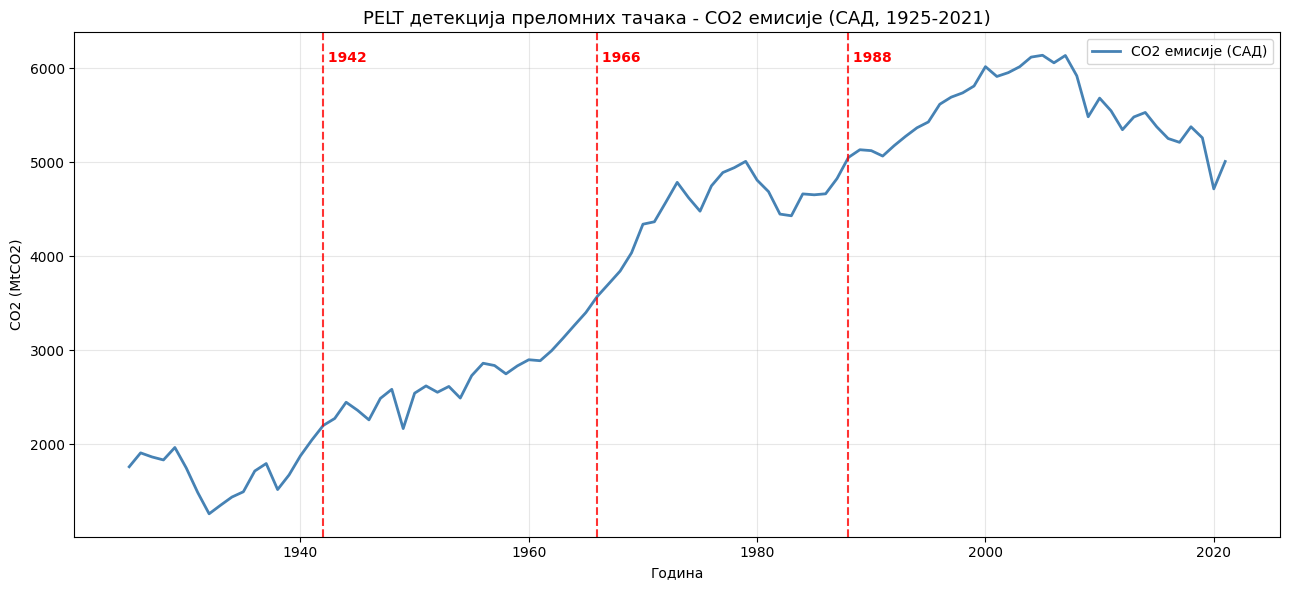

✓ Слика сачувана: pelt_usa.png
China              (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1974), np.int64(1992), np.int64(2005)]


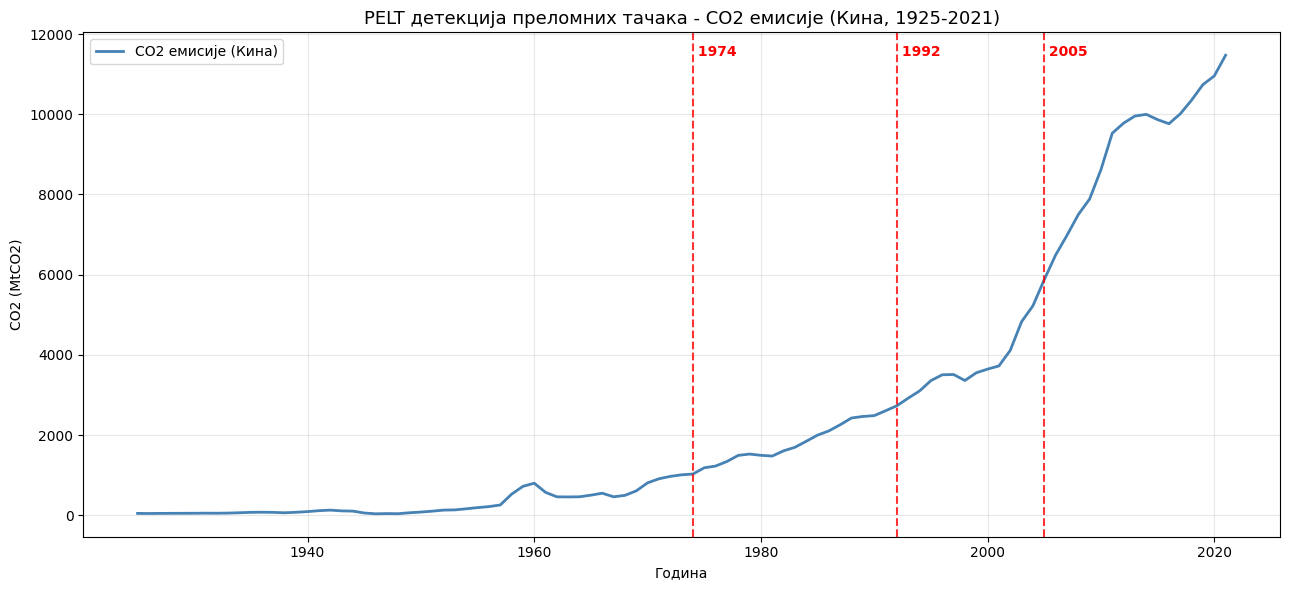

✓ Слика сачувана: pelt_china.png
Russia             (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1955), np.int64(1971), np.int64(1993)]


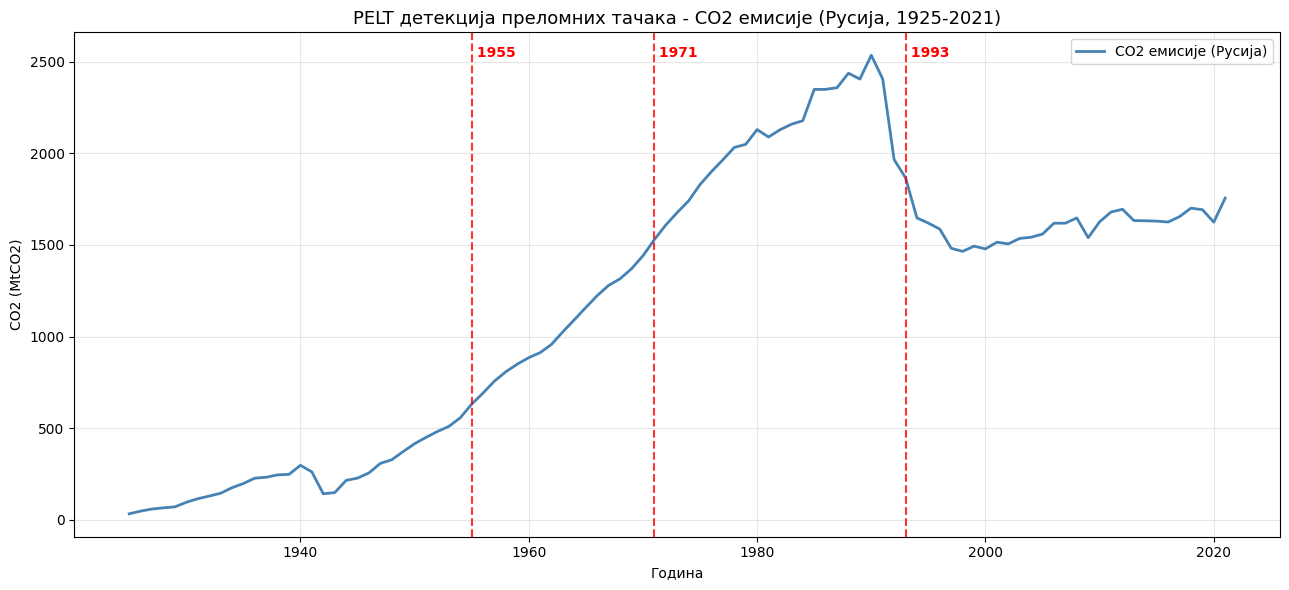

✓ Слика сачувана: pelt_russia.png
United Kingdom     (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1950), np.int64(2008)]


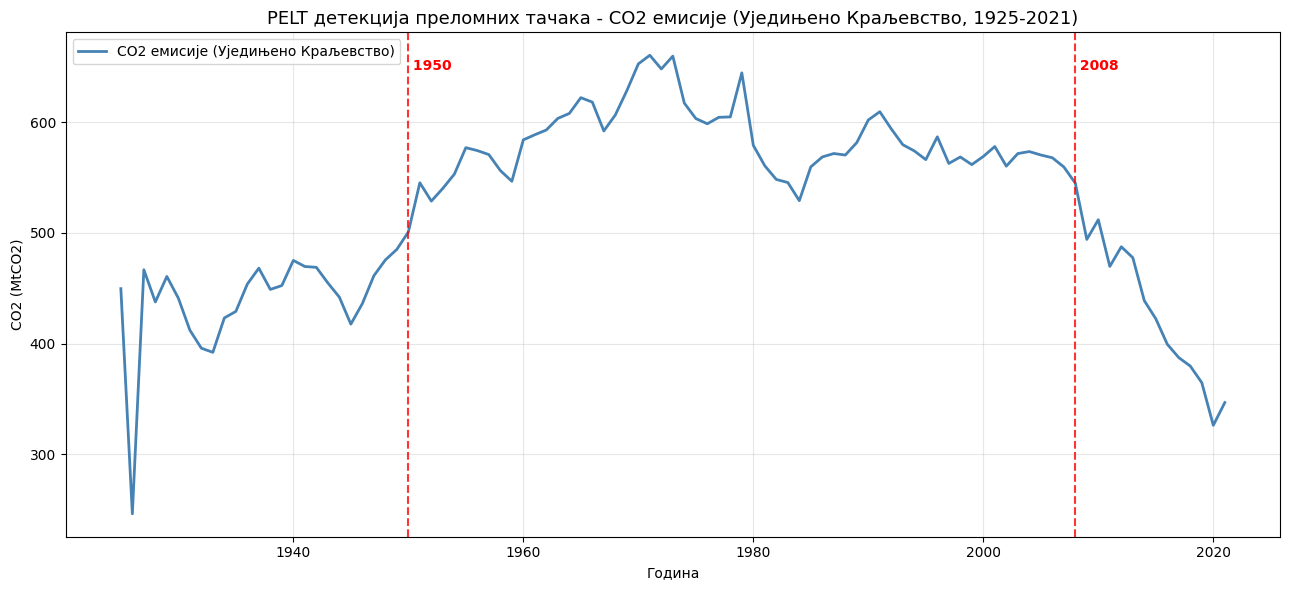

✓ Слика сачувана: pelt_united_kingdom.png
India              (1925-2021, 97 god.) → Prelomne tačke: [np.int64(1979), np.int64(1994), np.int64(2008)]


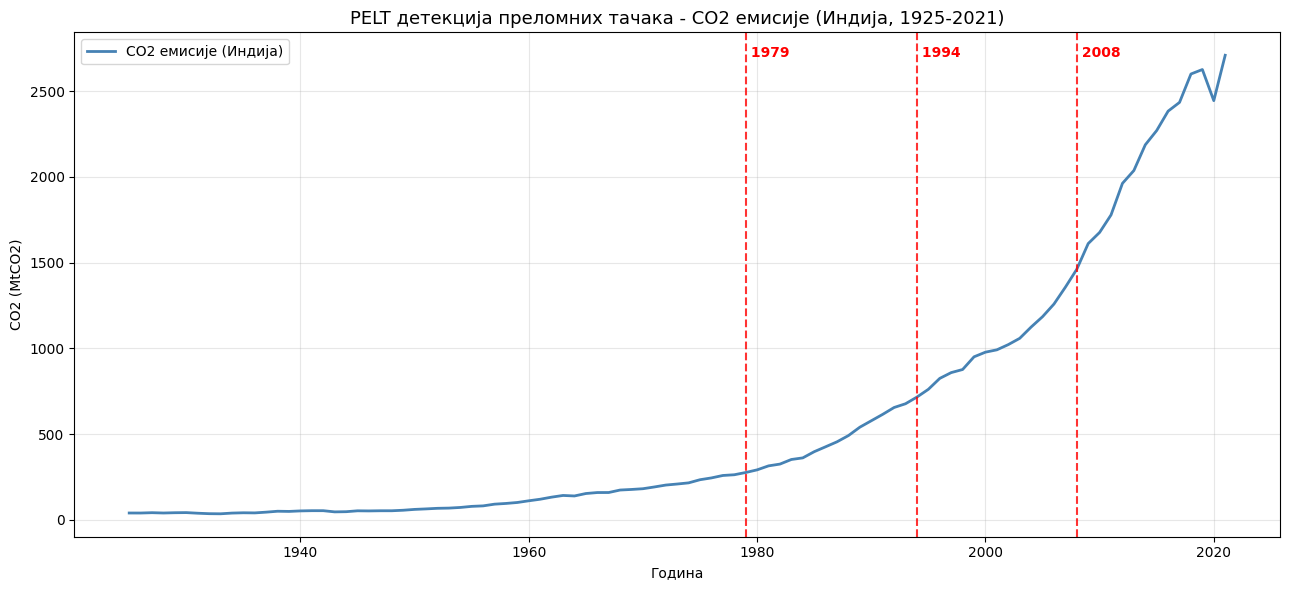

✓ Слика сачувана: pelt_india.png


In [80]:
# PELT MULTI-COUNTRY PREGLED - засебна слика за сваку државу

drzave_za_analizu = ['USA', 'China', 'Russia', 'United Kingdom', 'India']

# Речник са преводима назива држава на српски
nazivi_srpski = {
    'USA': 'САД',
    'China': 'Кина',
    'Russia': 'Русија',
    'United Kingdom': 'Уједињено Краљевство',
    'India': 'Индија'
}

rezultati_pelt = {}

for drzava in drzave_za_analizu:
    serija = df_ts[df_ts['Country'] == drzava].sort_values('Year')
    co2 = serija['Total'].values
    god = serija['Year'].values.astype(int)

    # PELT detekcija
    model = rpt.Pelt(model="rbf", min_size=3, jump=1).fit(co2)
    bkps = model.predict(pen=5)
    bkp_godine = [god[bp - 1] for bp in bkps[:-1]]

    rezultati_pelt[drzava] = {
        'godine': god,
        'co2': co2,
        'prelomne_godine': bkp_godine
    }

    naziv_sr = nazivi_srpski[drzava]
    print(f"{drzava:<18} ({god[0]}-{god[-1]}, {len(co2)} god.) → Prelomne tačke: {bkp_godine}")

    # Засебна слика за сваку државу
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(god, co2, color='steelblue', linewidth=2,
            label=f'CO2 емисије ({naziv_sr})')

    for by in bkp_godine:
        ax.axvline(x=by, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
        ax.text(by, ax.get_ylim()[1] * 0.95, f' {by}',
                color='red', fontsize=10, fontweight='bold')

    ax.set_title(f'PELT детекција преломних тачака - CO2 емисије ({naziv_sr}, 1925-2021)',
                 fontsize=13)
    ax.set_xlabel('Година')
    ax.set_ylabel('CO2 (MtCO2)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    naziv_fajla = f"pelt_{drzava.lower().replace(' ', '_')}.png"
    plt.savefig(naziv_fajla, dpi=150)
    plt.show()
    print(f"✓ Слика сачувана: {naziv_fajla}")

Број редова пре филтрирања outliera: 14093
Опсег GDP per capita: 5 - 14148075

Broj redova za EKC analizu: 13007
Novi opseg GDP per capita: 5 - 199375
Opseg CO2 per capita: 0.000 - 120.383

REZULTATI KVADRATNE REGRESIJE (EKC) - centrirano, bez outliera
                            OLS Regression Results                            
Dep. Variable:             Per Capita   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     2582.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:39:09   Log-Likelihood:                -40642.
No. Observations:               13007   AIC:                         8.129e+04
Df Residuals:                   13004   BIC:                         8.131e+04
Df Model:                           2                                         
Covariance Type:            nonrobus

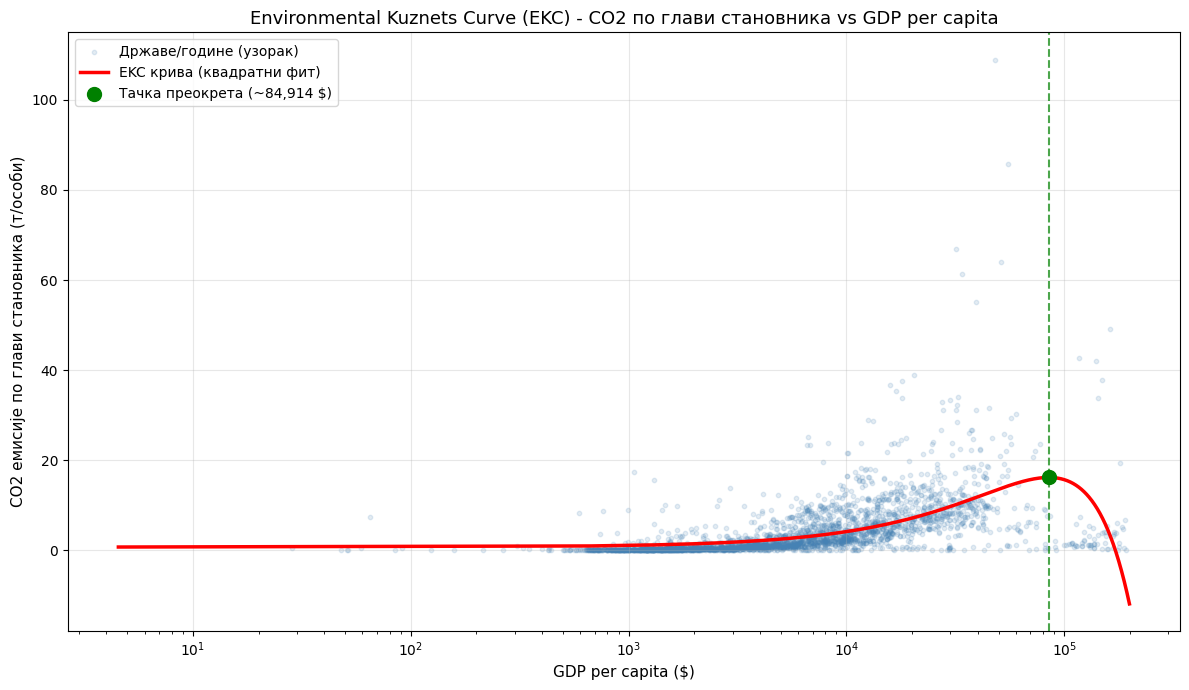


✓ Slika sacuvana: ekc_01_kuznets_curve.png


In [81]:
# DEO 4 - KUZNETSOVA KRIVA (Environmental Kuznets Curve - EKC)
# Testiramo hipotezu da CO2 per capita ima odnos oblika obrnutog "U"
# sa GDP per capita: emisije prvo rastu sa razvojem, a nakon odredjenog nivoa BDP-a pocinju da opadaju.
# Model: CO2pc = b0 + b1*GDPpc + b2*GDPpc^2 + e
# Ako je b1 > 0 i b2 < 0 (oba statisticki znacajna) -> EKC potvrdjena

# Racunamo GDP per capita i koristimo postojecu CO2 per capita ('Per Capita')
df_ekc = df_ts.copy()
df_ekc['gdp_per_capita'] = df_ekc['gdp'] / df_ekc['population']

# Uklanjamo redove sa nevalidnim vrednostima (0, negativne, NaN, inf)
df_ekc = df_ekc[
    (df_ekc['gdp_per_capita'] > 0) &
    (df_ekc['Per Capita'] > 0) &
    np.isfinite(df_ekc['gdp_per_capita']) &
    np.isfinite(df_ekc['Per Capita'])
].copy()

print(f"Број редова пре филтрирања outliera: {df_ekc.shape[0]}")
print(f"Опсег GDP per capita: {df_ekc['gdp_per_capita'].min():.0f} - {df_ekc['gdp_per_capita'].max():.0f}")

# Dodatni filter - uklanjamo nerealne GDP per capita vrednosti
# Realan opseg: do ~200,000 $ (najbogatije zemlje u svetu, npr. Luksemburg ~130k)
df_ekc = df_ekc[df_ekc['gdp_per_capita'] < 200000].copy()

print(f"\nBroj redova za EKC analizu: {df_ekc.shape[0]}")
print(f"Novi opseg GDP per capita: {df_ekc['gdp_per_capita'].min():.0f} - {df_ekc['gdp_per_capita'].max():.0f}")
print(f"Opseg CO2 per capita: {df_ekc['Per Capita'].min():.3f} - {df_ekc['Per Capita'].max():.3f}")

# KVADRATNA REGRESIJA - sa centriranjem (resava multikolinearnost)

df_ekc['gdp_pc_scaled'] = df_ekc['gdp_per_capita'] / 1000
gdp_mean = df_ekc['gdp_pc_scaled'].mean()
df_ekc['gdp_pc_centered'] = df_ekc['gdp_pc_scaled'] - gdp_mean

X = df_ekc[['gdp_pc_centered']].copy()
X['gdp_pc_centered_sq'] = X['gdp_pc_centered'] ** 2
X = sm.add_constant(X)
y = df_ekc['Per Capita']

ekc_model = OLS(y, X).fit()

print("\n" + "=" * 60)
print("REZULTATI KVADRATNE REGRESIJE (EKC) - centrirano, bez outliera")
print("=" * 60)
print(ekc_model.summary())

# TACKA PREOKRETA (TURNING POINT)

b1 = ekc_model.params['gdp_pc_centered']
b2 = ekc_model.params['gdp_pc_centered_sq']

turning_point_centered = -b1 / (2 * b2)
turning_point_gdp = (turning_point_centered + gdp_mean) * 1000

print("\n" + "=" * 60)
print("ZAKLJUCAK")
print("=" * 60)
print(f"b1 (linearni koeficijent)  = {b1:.6f}  (p = {ekc_model.pvalues['gdp_pc_centered']:.2e})")
print(f"b2 (kvadratni koeficijent) = {b2:.6f}  (p = {ekc_model.pvalues['gdp_pc_centered_sq']:.2e})")

if b1 > 0 and b2 < 0:
    print("\n-> b1 > 0 i b2 < 0: EKC hipoteza je POTVRDJENA (kriva oblika obrnutog U)")
    print(f"-> Tacka preokreta: {turning_point_gdp:,.0f} $ GDP per capita")
    print("   Iznad ovog nivoa GDP-a, CO2 per capita pocinje da OPADA")
else:
    print("\n-> Koeficijenti ne odgovaraju EKC obrascu - hipoteza NIJE potvrdjena")

print(f"\nR-squared = {ekc_model.rsquared:.4f}")
print("(Nizak R^2 je ocekivan - GDP per capita je samo jedan od mnogo faktora")
print(" koji uticu na emisije CO2, ali odnos je statisticki znacajan)")

# VIZUALIZACIJA - EKC kriva

gdp_range = np.linspace(df_ekc['gdp_per_capita'].min(), df_ekc['gdp_per_capita'].max(), 300)
gdp_range_scaled = gdp_range / 1000
gdp_range_centered = gdp_range_scaled - gdp_mean

co2_predicted = (
    ekc_model.params['const'] +
    b1 * gdp_range_centered +
    b2 * gdp_range_centered ** 2
)

fig, ax = plt.subplots(figsize=(12, 7))

sample = df_ekc.sample(min(3000, len(df_ekc)), random_state=42)
ax.scatter(sample['gdp_per_capita'], sample['Per Capita'],
           alpha=0.15, s=10, color='steelblue', label='Државе/године (узорак)')

ax.plot(gdp_range, co2_predicted, color='red', linewidth=2.5,
        label='EKC крива (квадратни фит)')

if b2 < 0 and df_ekc['gdp_per_capita'].min() < turning_point_gdp < df_ekc['gdp_per_capita'].max():
    co2_at_turning = (ekc_model.params['const'] +
                      b1 * turning_point_centered +
                      b2 * turning_point_centered ** 2)
    ax.axvline(x=turning_point_gdp, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.scatter([turning_point_gdp], [co2_at_turning], color='green', s=100, zorder=5,
               label=f'Тачка преокрета (~{turning_point_gdp:,.0f} $)')

ax.set_xlabel('GDP per capita ($)', fontsize=11)
ax.set_ylabel('CO2 емисије по глави становника (т/особи)', fontsize=11)
ax.set_title('Environmental Kuznets Curve (EKC) - CO2 по глави становника vs GDP per capita', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig("ekc_01_kuznets_curve.png", dpi=150)
plt.show()
print("\n✓ Slika sacuvana: ekc_01_kuznets_curve.png")

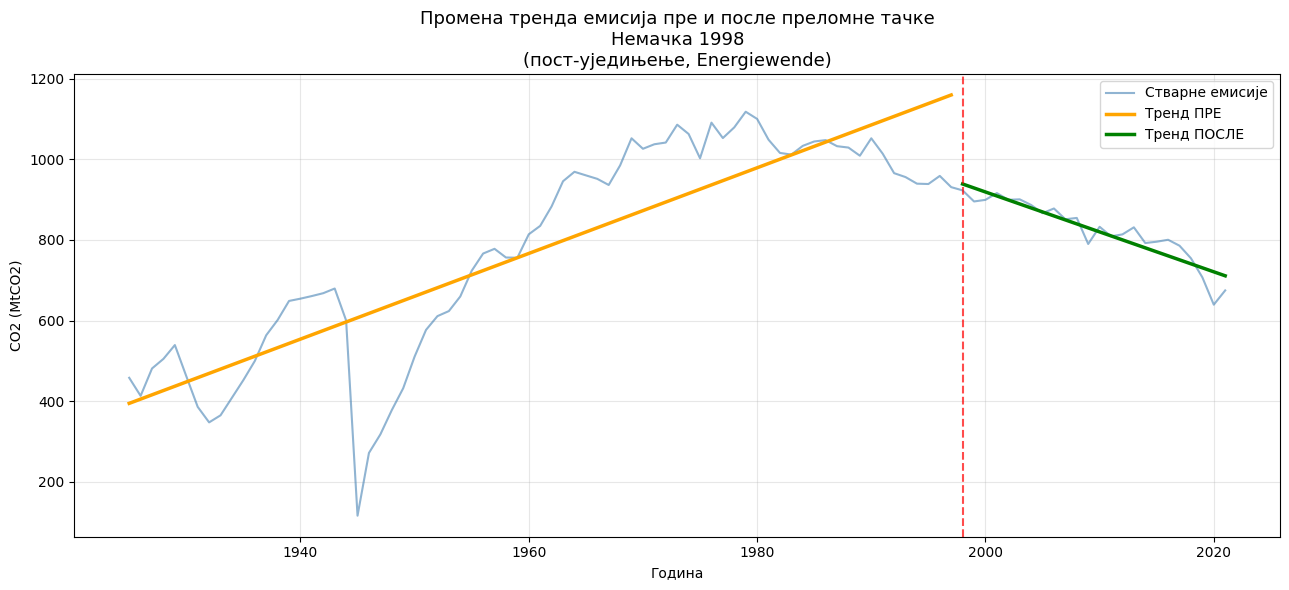

✓ Слика сачувана: efikasnost_germany.png


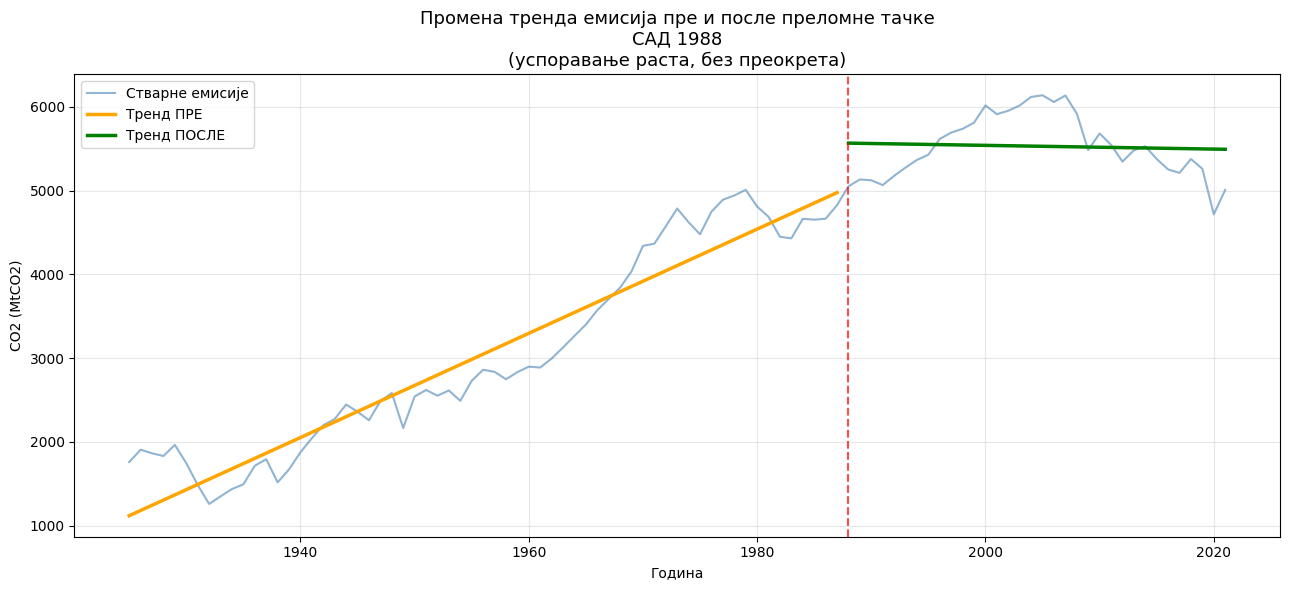

✓ Слика сачувана: efikasnost_usa.png


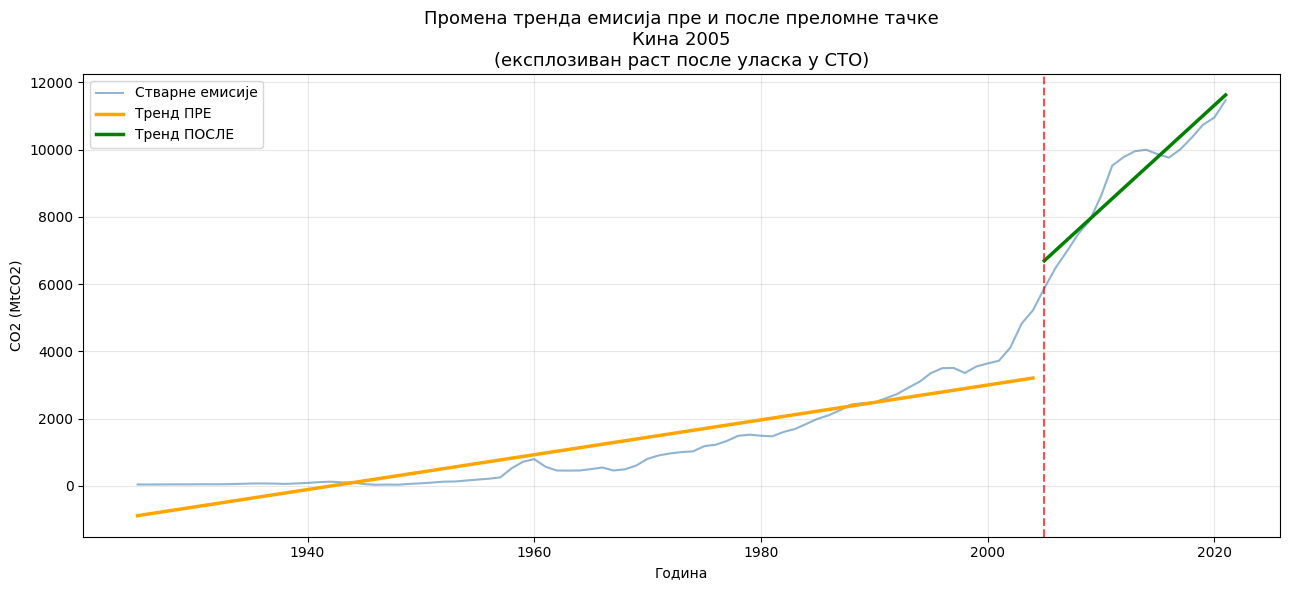

✓ Слика сачувана: efikasnost_china.png


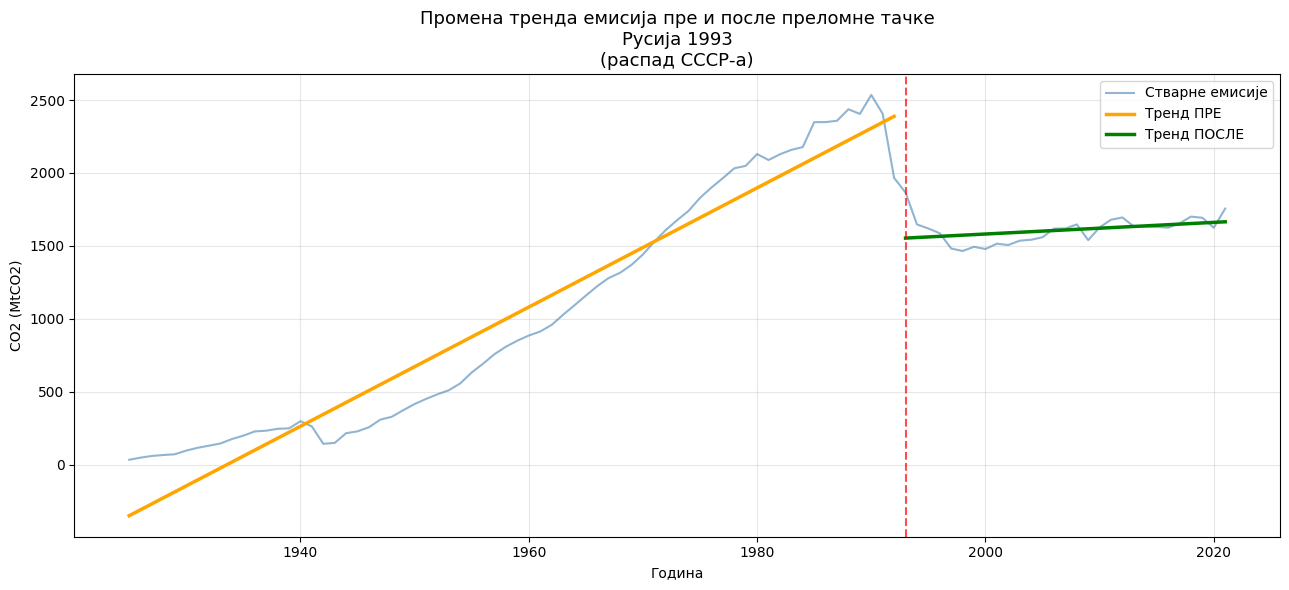

✓ Слика сачувана: efikasnost_russia.png


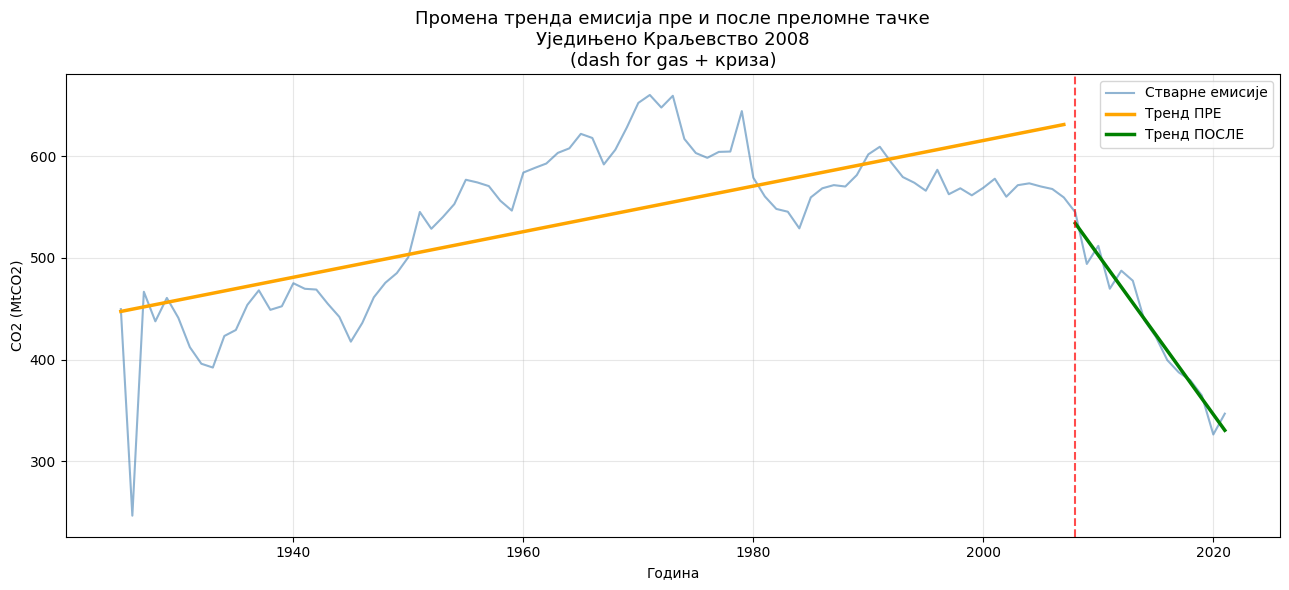

✓ Слика сачувана: efikasnost_uk.png


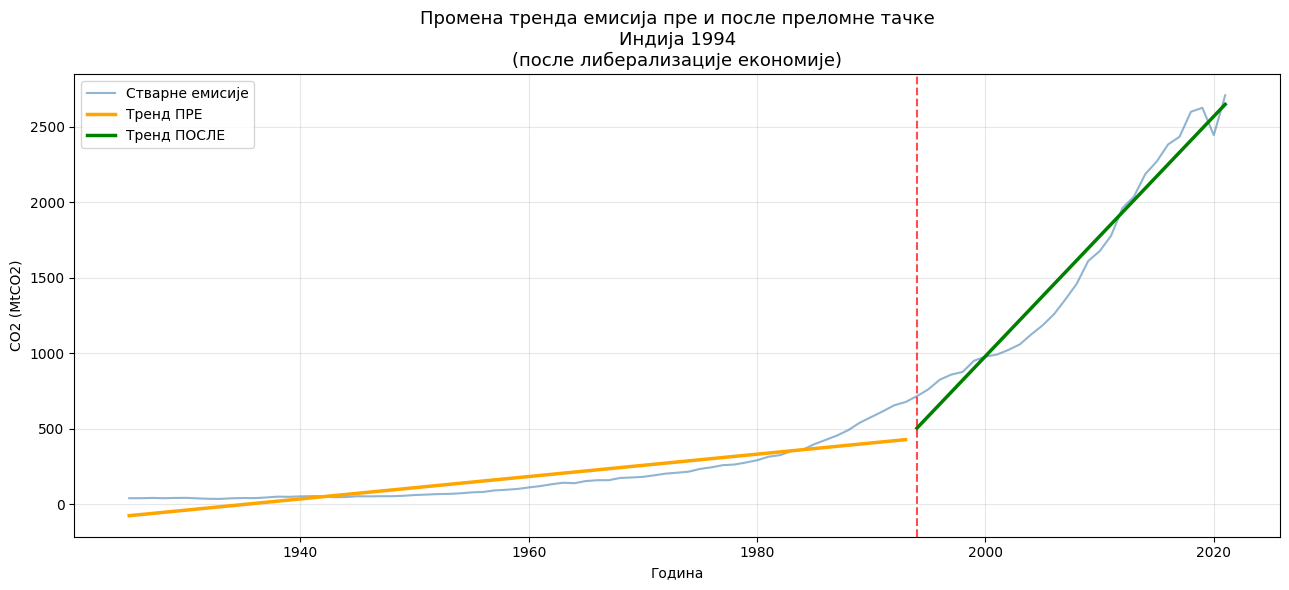

✓ Слика сачувана: efikasnost_india.png

        Država  Prelomna tačka  Nagib pre  Nagib posle  Razlika
       Germany            1998      10.62        -9.90   -20.52
           USA            1988      62.21        -2.22   -64.43
         China            2005      51.81       308.18   256.37
        Russia            1993      40.88         3.99   -36.89
United Kingdom            2008       2.24       -15.67   -17.91
         India            1994       7.41        79.45    72.04


In [ ]:
# ВИЗУАЛИЗАЦИЈА - засебна слика за свих 6 држава
# Изабрана преломна тачка за сваку државу је она са најјасније идентификованим узроком
# (наменска еколошка политика, или конкретан економски/политички шок)

slucajevi = [
    ('Germany',        1998, "Немачка 1998\n(пост-уједињење, Energiewende)"),
    ('USA',            1988, "САД 1988\n(успоравање раста, без преокрета)"),
    ('China',          2005, "Кина 2005\n(експлозиван раст после уласка у СТО)"),
    ('Russia',         1993, "Русија 1993\n(распад СССР-а)"),
    ('United Kingdom', 2008, "Уједињено Краљевство 2008\n(dash for gas + криза)"),
    ('India',          1994, "Индија 1994\n(после либерализације економије)")
]

nazivi_fajlova = {
    'Germany': 'efikasnost_germany.png',
    'USA': 'efikasnost_usa.png',
    'China': 'efikasnost_china.png',
    'Russia': 'efikasnost_russia.png',
    'United Kingdom': 'efikasnost_uk.png',
    'India': 'efikasnost_india.png'
}

rezultati_trend = []

for drzava, godina, naslov in slucajevi:
    serija = df_ts[df_ts['Country'] == drzava].sort_values('Year')
    pre = serija[serija['Year'] < godina]
    posle = serija[serija['Year'] >= godina]

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(serija['Year'], serija['Total'],
            color='steelblue', linewidth=1.5, alpha=0.6,
            label='Стварне емисије')

    nagib_pre = nagib_posle = None

    if len(pre) >= 2:
        z_pre = np.polyfit(pre['Year'], pre['Total'], 1)
        nagib_pre = z_pre[0]
        ax.plot(pre['Year'], np.polyval(z_pre, pre['Year']),
                color='orange', linewidth=2.5, label='Тренд ПРЕ')

    if len(posle) >= 2:
        z_posle = np.polyfit(posle['Year'], posle['Total'], 1)
        nagib_posle = z_posle[0]
        ax.plot(posle['Year'], np.polyval(z_posle, posle['Year']),
                color='green', linewidth=2.5, label='Тренд ПОСЛЕ')

    ax.axvline(x=godina, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_title(f'Промена тренда емисија пре и после преломне тачке\n{naslov}',
                 fontsize=13)
    ax.set_xlabel('Година')
    ax.set_ylabel('CO2 (MtCO2)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    naziv_fajla = nazivi_fajlova[drzava]
    plt.savefig(naziv_fajla, dpi=150)
    plt.show()
    print(f"Слика сачувана: {naziv_fajla}")

    rezultati_trend.append({
        'Država': drzava,
        'Prelomna tačka': godina,
        'Nagib pre': round(nagib_pre, 2) if nagib_pre is not None else None,
        'Nagib posle': round(nagib_posle, 2) if nagib_posle is not None else None,
        'Razlika': round(nagib_posle - nagib_pre, 2) if (nagib_pre is not None and nagib_posle is not None) else None
    })

df_rezultati_trend = pd.DataFrame(rezultati_trend)
print("\n" + "="*60)
print(df_rezultati_trend.to_string(index=False))


ARIMA - Немачка
Број предвиђања: 87
MAE:  49.27 MtCO2
RMSE: 91.99 MtCO2
MAPE: 11.96%


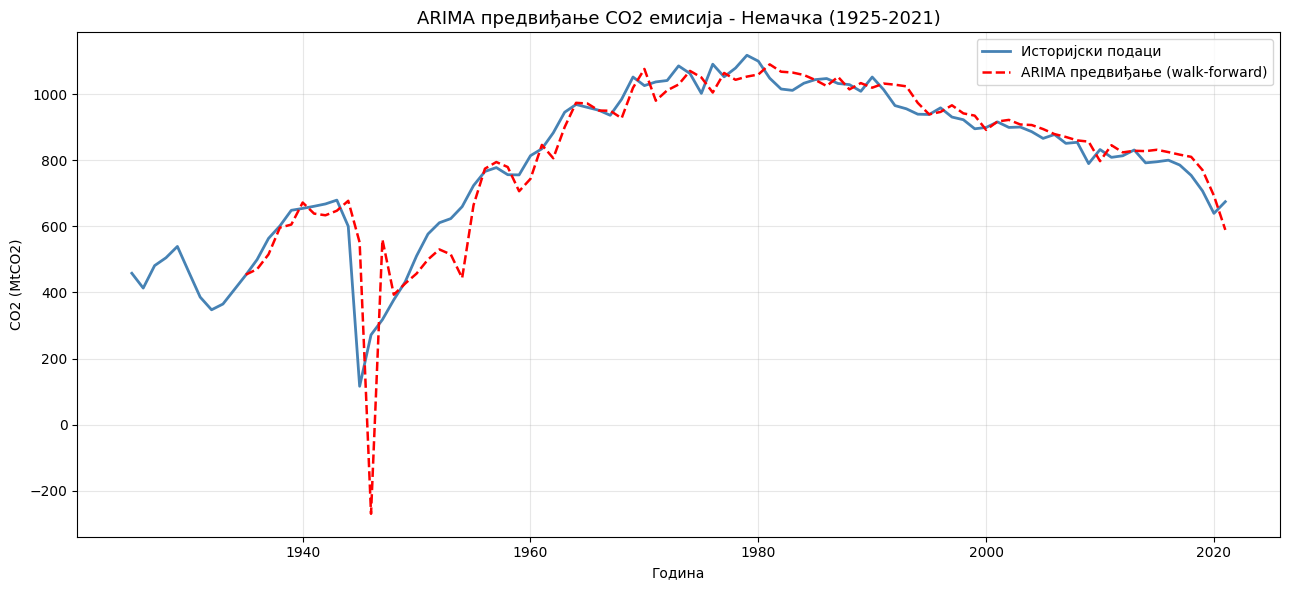

Слика сачувана: arima_germany.png

ARIMA - САД
Број предвиђања: 87
MAE:  154.96 MtCO2
RMSE: 200.77 MtCO2
MAPE: 4.54%


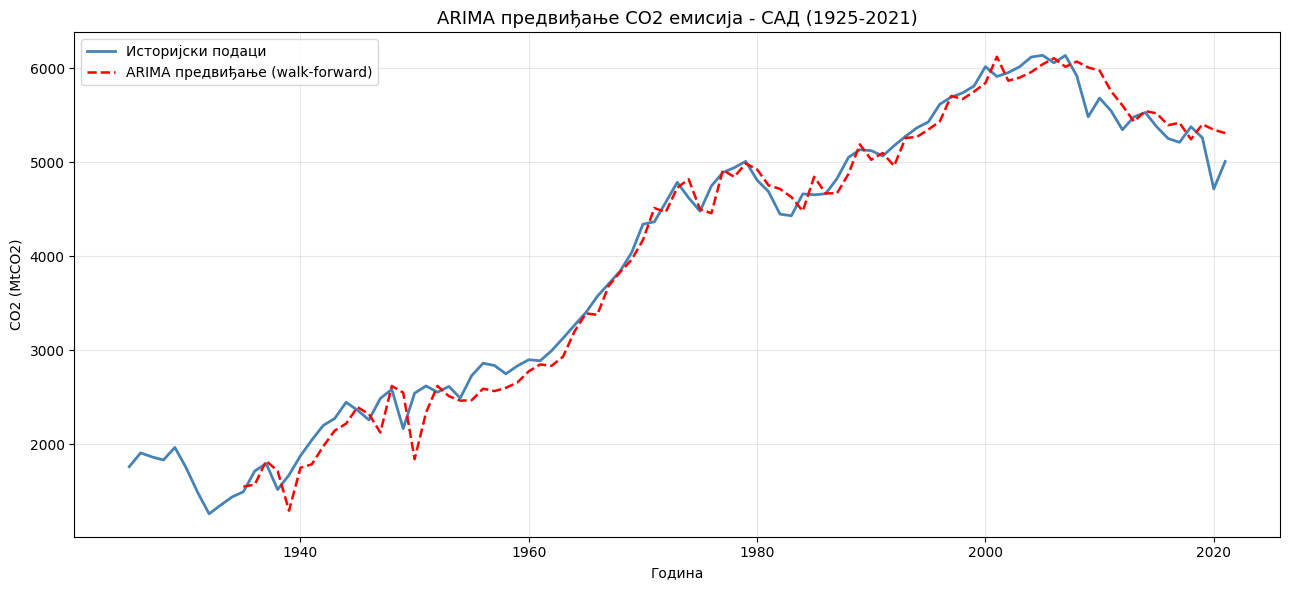

Слика сачувана: arima_usa.png

ARIMA - Кина
Број предвиђања: 87
MAE:  120.93 MtCO2
RMSE: 186.57 MtCO2
MAPE: 11.16%


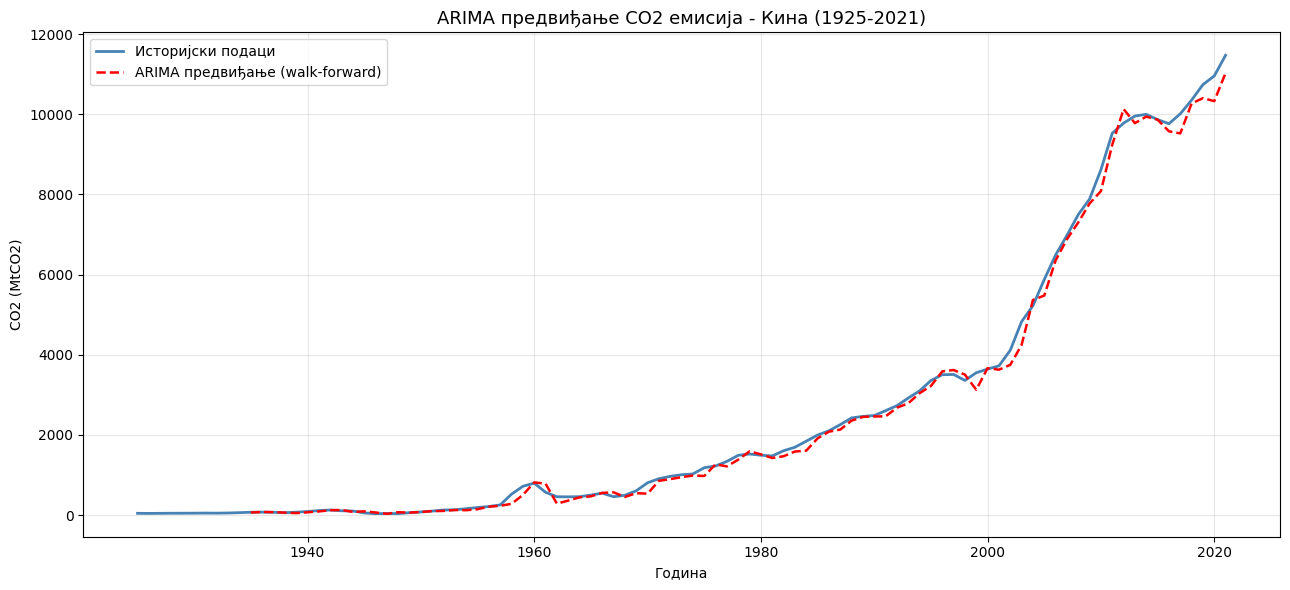

Слика сачувана: arima_china.png

ARIMA - Русија
Број предвиђања: 87
MAE:  59.58 MtCO2
RMSE: 112.46 MtCO2
MAPE: 6.73%


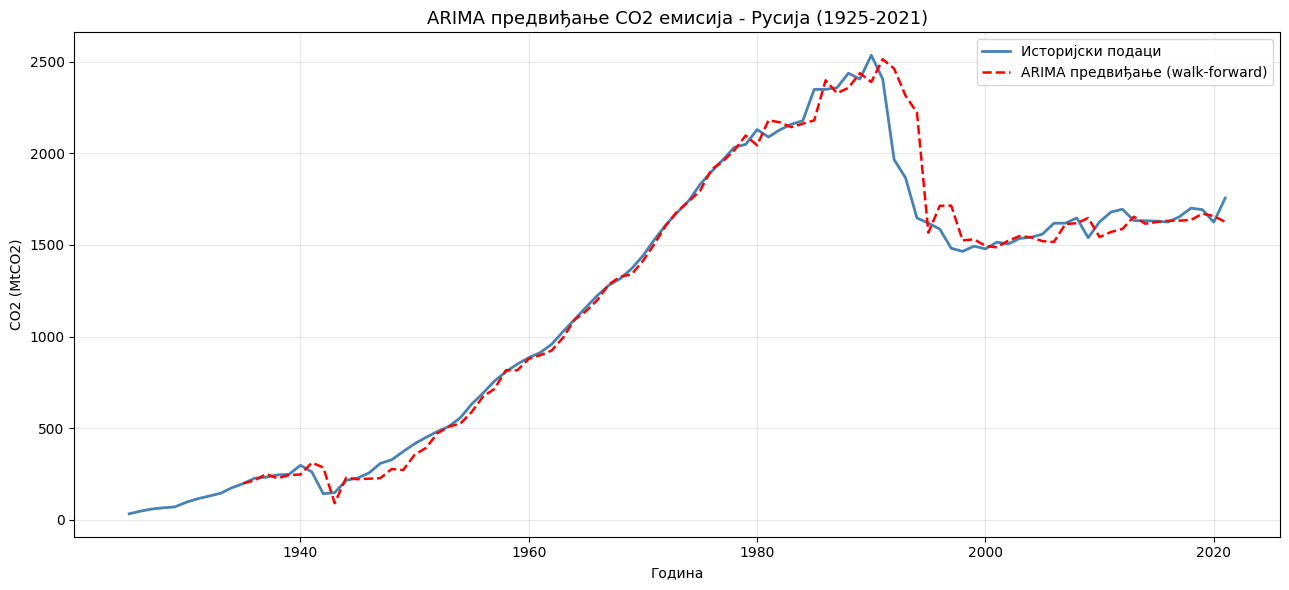

Слика сачувана: arima_russia.png

ARIMA - Уједињено Краљевство
Број предвиђања: 87
MAE:  20.30 MtCO2
RMSE: 26.46 MtCO2
MAPE: 3.91%


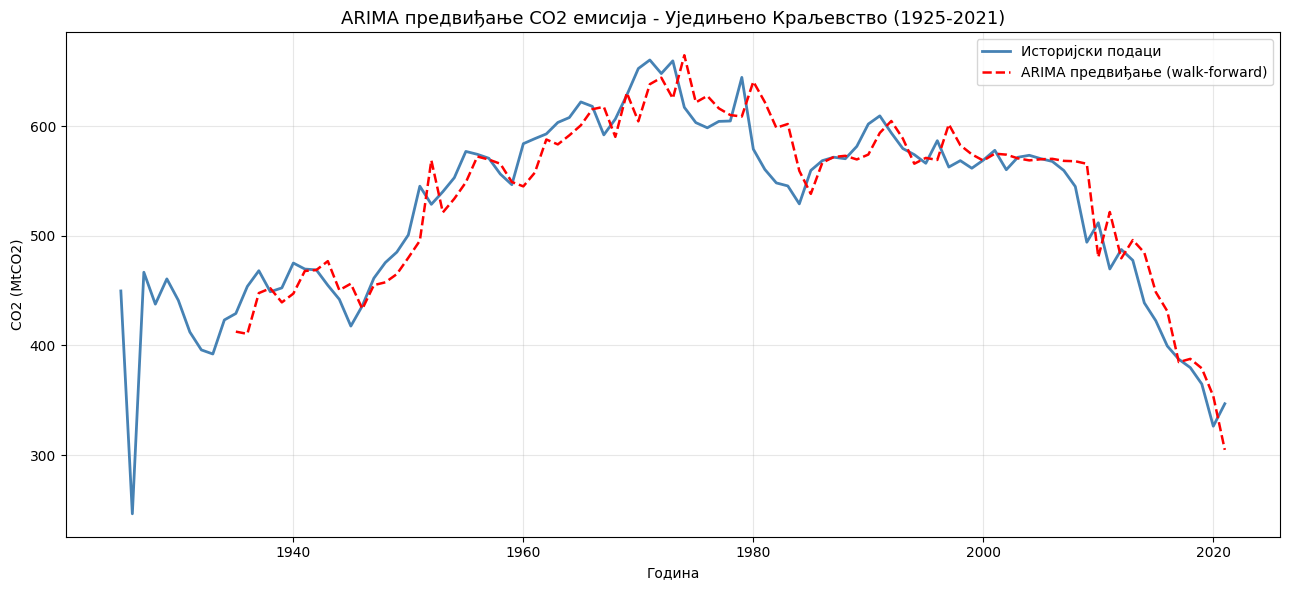

Слика сачувана: arima_united_kingdom.png

ARIMA - Индија
Број предвиђања: 87
MAE:  26.23 MtCO2
RMSE: 69.33 MtCO2
MAPE: 4.14%


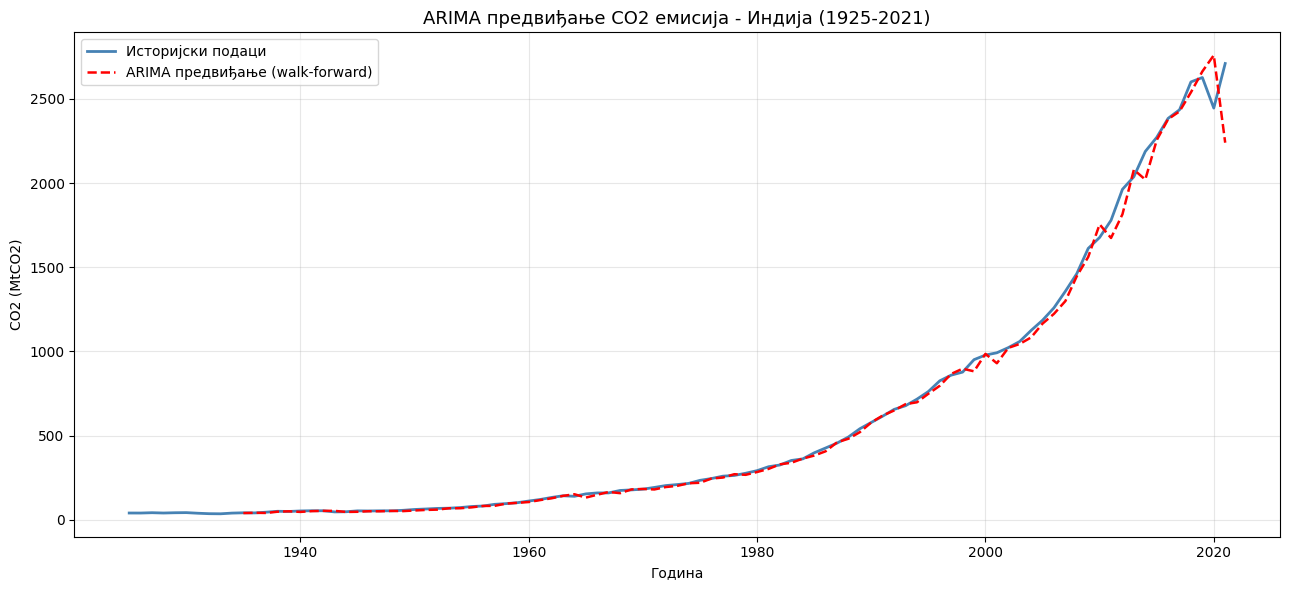

Слика сачувана: arima_india.png

ФИНАЛНА ТАБЕЛА - ARIMA резултати (Walk-forward)
Држава                         MAE     RMSE   MAPE (%)
-------------------------------------------------------
Немачка                      49.27    91.99      11.96
САД                         154.96   200.77       4.54
Кина                        120.93   186.57      11.16
Русија                       59.58   112.46       6.73
Уједињено Краљевство         20.30    26.46       3.91
Индија                       26.23    69.33       4.14


In [ ]:
# ARIMA ПРЕДВИЂАЊЕ - WALK-FORWARD ВАЛИДАЦИЈА

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

drzave_arima = ['Germany', 'USA', 'China', 'Russia', 'United Kingdom', 'India']

nazivi_srpski = {
    'Germany': 'Немачка',
    'USA': 'САД',
    'China': 'Кина',
    'Russia': 'Русија',
    'United Kingdom': 'Уједињено Краљевство',
    'India': 'Индија'
}

WINDOW = 10  # прозор од 10 претходних година

rezultati_arima = {}

for drzava in drzave_arima:
    naziv_sr = nazivi_srpski[drzava]

    print(f"\n{'='*55}")
    print(f"ARIMA - {naziv_sr}")
    print(f"{'='*55}")

    serija = df_ts[df_ts['Country'] == drzava].sort_values('Year')
    co2 = serija['Total'].values
    years = serija['Year'].values.astype(int)

    predvidjanja = []
    stvarne = []
    godine_pred = []

    # Walk-forward валидација
    for i in range(WINDOW, len(co2)):
        prozor = co2[i - WINDOW : i]  # 10 претходних година
        stvarna = co2[i]               # следећа година

        # ARIMA на тренутном прозору
        try:
            model = auto_arima(
                prozor,
                seasonal=False,
                stepwise=True,
                suppress_warnings=True,
                error_action='ignore',
                information_criterion='aic'
            )
            pred = model.predict(n_periods=1)[0]
        except:
            pred = prozor[-1]  # ако модел не конвергира, узми последњу вредност

        predvidjanja.append(pred)
        stvarne.append(stvarna)
        godine_pred.append(years[i])

    predvidjanja = np.array(predvidjanja)
    stvarne = np.array(stvarne)

    # Метрике
    mae  = mean_absolute_error(stvarne, predvidjanja)
    rmse = np.sqrt(mean_squared_error(stvarne, predvidjanja))
    mape = np.mean(np.abs((stvarne - predvidjanja) / stvarne)) * 100

    print(f"Број предвиђања: {len(predvidjanja)}")
    print(f"MAE:  {mae:.2f} MtCO2")
    print(f"RMSE: {rmse:.2f} MtCO2")
    print(f"MAPE: {mape:.2f}%")

    rezultati_arima[drzava] = {
        'predvidjanja': predvidjanja,
        'stvarne': stvarne,
        'godine': np.array(godine_pred),
        'mae': mae,
        'rmse': rmse,
        'mape': mape
    }

    # Визуализација
    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(years, co2,
            color='steelblue', linewidth=2, label='Историјски подаци')
    ax.plot(godine_pred, predvidjanja,
            color='red', linestyle='--', linewidth=1.8,
            label='ARIMA предвиђање (walk-forward)')

    ax.set_title(f"ARIMA предвиђање CO2 емисија - {naziv_sr} (1925-2021)",
                 fontsize=13)
    ax.set_xlabel('Година')
    ax.set_ylabel('CO2 (MtCO2)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    naziv_fajla = f"arima_{drzava.lower().replace(' ', '_')}.png"
    plt.savefig(naziv_fajla, dpi=150)
    plt.show()
    print(f"Слика сачувана: {naziv_fajla}")


# ФИНАЛНА ТАБЕЛА

print("\n" + "=" * 55)
print("ФИНАЛНА ТАБЕЛА - ARIMA резултати (Walk-forward)")
print("=" * 55)
print(f"{'Држава':<25} {'MAE':>8} {'RMSE':>8} {'MAPE (%)':>10}")
print("-" * 55)
for drzava in drzave_arima:
    naziv_sr = nazivi_srpski[drzava]
    r = rezultati_arima[drzava]
    print(f"{naziv_sr:<25} {r['mae']:>8.2f} {r['rmse']:>8.2f} {r['mape']:>10.2f}")
print("=" * 55)


LSTM — Немачка
Број предвиђања: 87
Број fallback предвиђања: 5
MAE:  69.47 MtCO2
RMSE: 128.18 MtCO2
MAPE: 11.74%


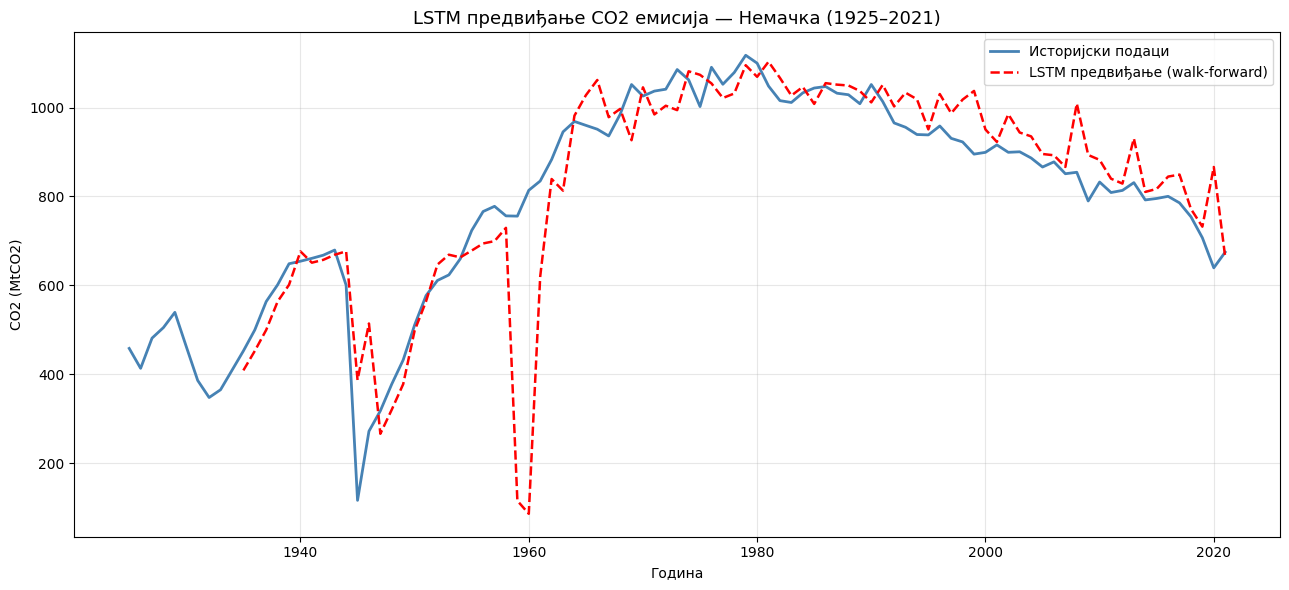

✓ Слика сачувана: lstm_germany.png

LSTM — САД
Број предвиђања: 87
Број fallback предвиђања: 5
MAE:  213.24 MtCO2
RMSE: 270.77 MtCO2
MAPE: 5.58%


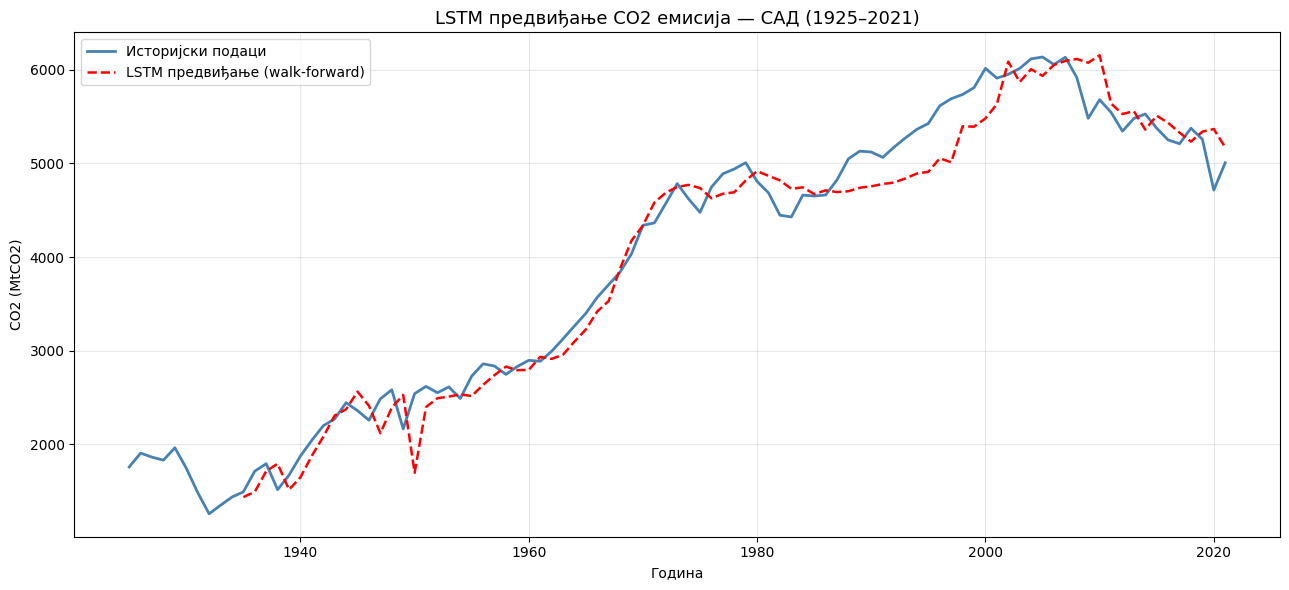

✓ Слика сачувана: lstm_usa.png

LSTM — Кина
Број предвиђања: 87
Број fallback предвиђања: 5
MAE:  176.71 MtCO2
RMSE: 289.79 MtCO2
MAPE: 14.05%


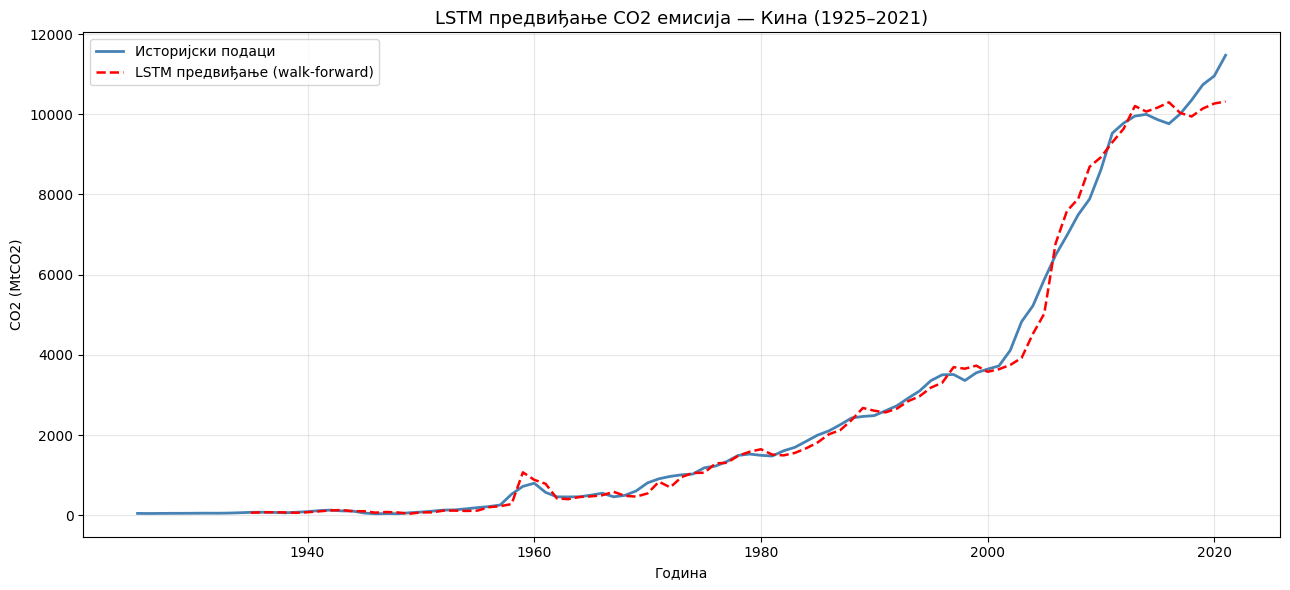

✓ Слика сачувана: lstm_china.png

LSTM — Русија
Број предвиђања: 87
Број fallback предвиђања: 5
MAE:  78.70 MtCO2
RMSE: 133.28 MtCO2
MAPE: 8.60%


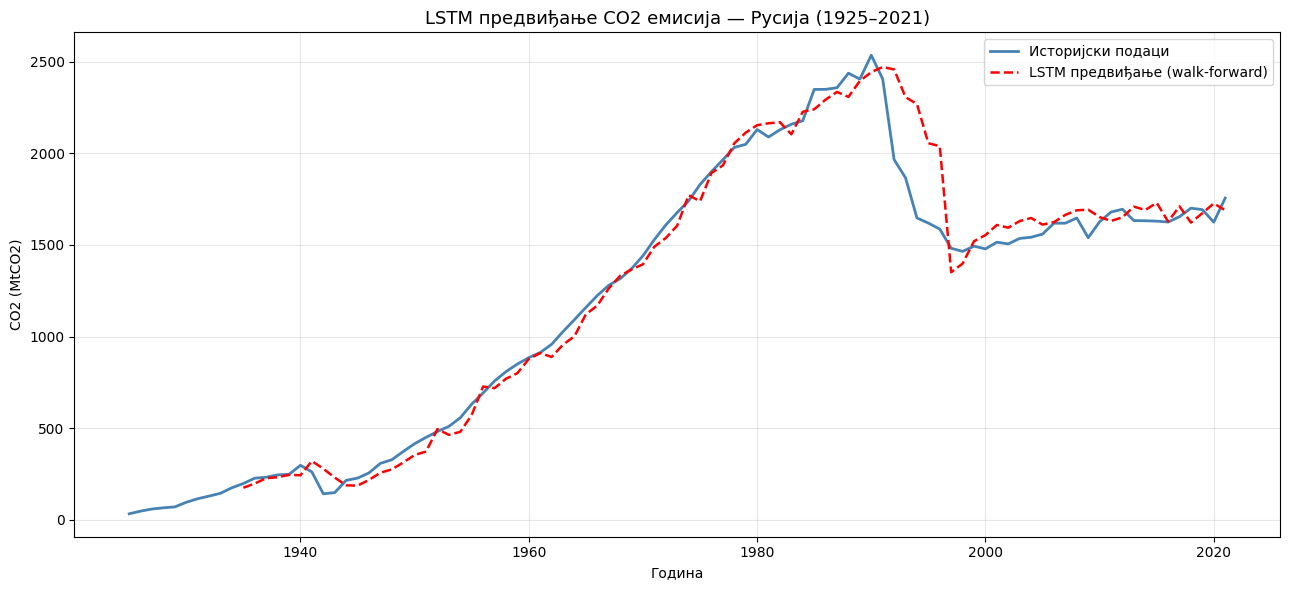

✓ Слика сачувана: lstm_russia.png

LSTM — Уједињено Краљевство
Број предвиђања: 87
Број fallback предвиђања: 5
MAE:  27.83 MtCO2
RMSE: 36.30 MtCO2
MAPE: 5.43%


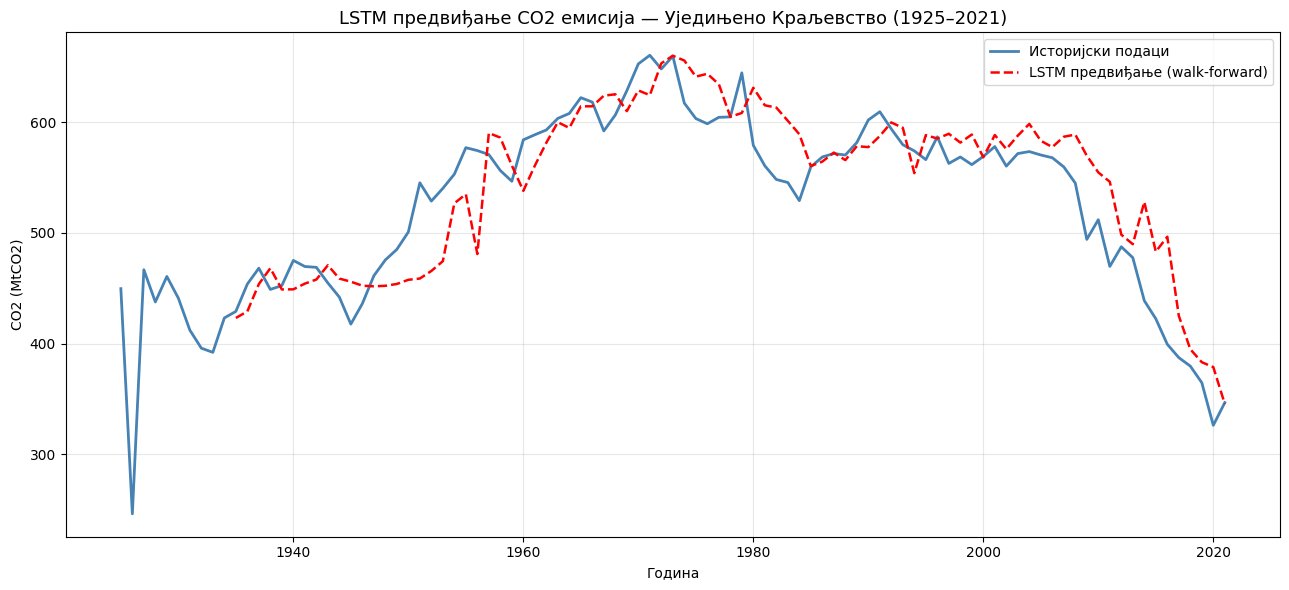

✓ Слика сачувана: lstm_united_kingdom.png

LSTM — Индија
Број предвиђања: 87
Број fallback предвиђања: 5
MAE:  25.47 MtCO2
RMSE: 49.23 MtCO2
MAPE: 4.22%


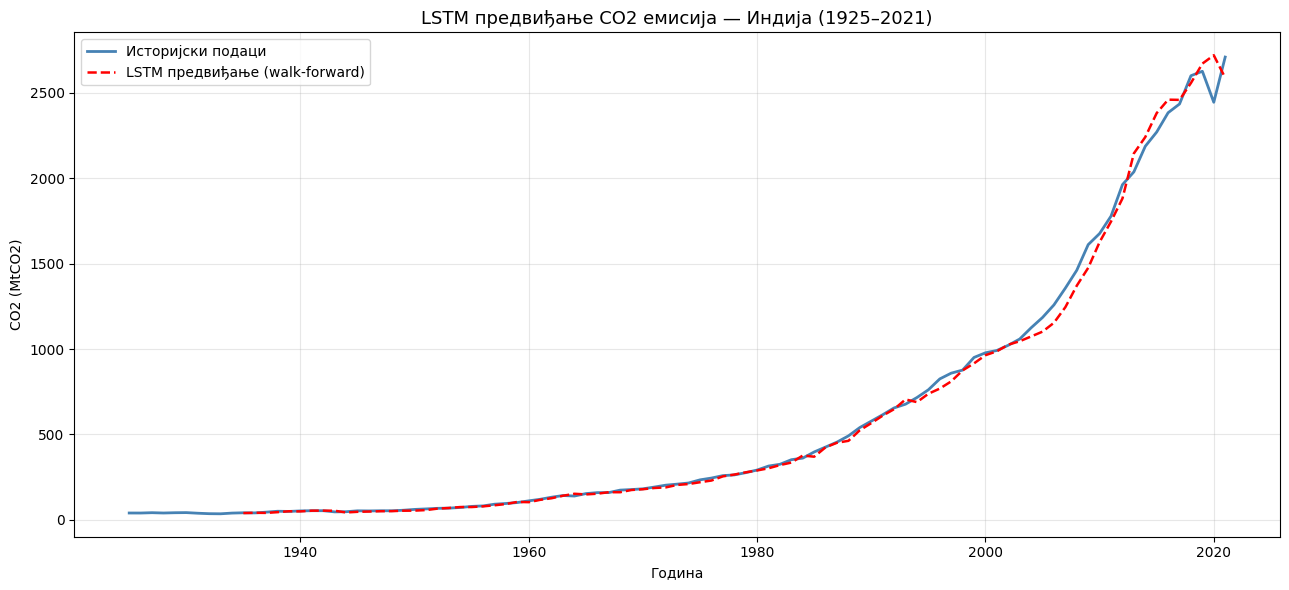

✓ Слика сачувана: lstm_india.png

ФИНАЛНА ТАБЕЛА — ARIMA vs LSTM (Walk-forward, прозор 10 год.)
Држава                     ARIMA MAE   LSTM MAE   ARIMA MAPE  LSTM MAPE
-----------------------------------------------------------------
Немачка                        49.27      69.47       11.96%     11.74%
САД                           154.96     213.24        4.54%      5.58%
Кина                          120.93     176.71       11.16%     14.05%
Русија                         59.58      78.70        6.73%      8.60%
Уједињено Краљевство           20.30      27.83        3.91%      5.43%
Индија                         26.23      25.47        4.14%      4.22%


In [ ]:
# LSTM ПРЕДВИЂАЊЕ - WALK-FORWARD ВАЛИДАЦИЈА (прозор 10 година)

import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

torch.manual_seed(42)
np.random.seed(42)

drzave_lstm = ['Germany', 'USA', 'China', 'Russia', 'United Kingdom', 'India']

nazivi_srpski = {
    'Germany': 'Немачка',
    'USA': 'САД',
    'China': 'Кина',
    'Russia': 'Русија',
    'United Kingdom': 'Уједињено Краљевство',
    'India': 'Индија'
}

WINDOW = 10
MIN_TRAIN_PAIRS = 5
EPOCHS = 150          
HIDDEN_SIZE = 64       
NUM_LAYERS = 2         
DROPOUT = 0.2          


def kreiraj_sekvence(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i: i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)


class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


rezultati_lstm = {}

for drzava in drzave_lstm:
    naziv_sr = nazivi_srpski[drzava]

    print(f"\n{'='*55}")
    print(f"LSTM — {naziv_sr}")
    print(f"{'='*55}")

    serija = df_ts[df_ts['Country'] == drzava].sort_values('Year')
    co2 = serija['Total'].values.reshape(-1, 1)
    years = serija['Year'].values.astype(int)

    predvidjanja = []
    stvarne = []
    godine_pred = []
    broj_fallback = 0

    for i in range(WINDOW, len(co2)):
        stvarna = co2[i]
        istorija = co2[:i]

        X_hist, y_hist = kreiraj_sekvence(istorija.flatten(), WINDOW)

        if len(X_hist) < MIN_TRAIN_PAIRS:
            pred_original = istorija[-1][0]
            broj_fallback += 1
        else:
            try:
                scaler = MinMaxScaler(feature_range=(0, 1))
                scaler.fit(istorija)

                X_hist_scaled = scaler.transform(X_hist.reshape(-1, 1)).reshape(X_hist.shape)
                y_hist_scaled = scaler.transform(y_hist.reshape(-1, 1))

                X_train = torch.FloatTensor(X_hist_scaled).unsqueeze(-1)
                y_train = torch.FloatTensor(y_hist_scaled)

                model = LSTMModel(input_size=1, hidden_size=HIDDEN_SIZE,
                                   num_layers=NUM_LAYERS, dropout=DROPOUT)
                optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
                loss_fn = nn.MSELoss()

                model.train()
                for epoch in range(EPOCHS):
                    optimizer.zero_grad()
                    pred = model(X_train)
                    loss = loss_fn(pred, y_train)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    prozor_test = co2[i - WINDOW: i]
                    prozor_test_scaled = scaler.transform(prozor_test)
                    X_pred = torch.FloatTensor(prozor_test_scaled).unsqueeze(0)
                    pred_scaled = model(X_pred).numpy()

                pred_original = scaler.inverse_transform(pred_scaled)[0][0]

            except Exception:
                pred_original = istorija[-1][0]
                broj_fallback += 1

        predvidjanja.append(pred_original)
        stvarne.append(stvarna[0])
        godine_pred.append(years[i])

    predvidjanja = np.array(predvidjanja)
    stvarne = np.array(stvarne)

    mae  = mean_absolute_error(stvarne, predvidjanja)
    rmse = np.sqrt(mean_squared_error(stvarne, predvidjanja))
    mape = np.mean(np.abs((stvarne - predvidjanja) / stvarne)) * 100

    print(f"Број предвиђања: {len(predvidjanja)}")
    print(f"Број fallback предвиђања: {broj_fallback}")
    print(f"MAE:  {mae:.2f} MtCO2")
    print(f"RMSE: {rmse:.2f} MtCO2")
    print(f"MAPE: {mape:.2f}%")

    rezultati_lstm[drzava] = {
        'predvidjanja': predvidjanja,
        'stvarne': stvarne,
        'godine': np.array(godine_pred),
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'broj_fallback': broj_fallback
    }

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(years, co2.flatten(),
            color='steelblue', linewidth=2, label='Историјски подаци')
    ax.plot(godine_pred, predvidjanja,
            color='red', linestyle='--', linewidth=1.8,
            label='LSTM предвиђање (walk-forward)')
    ax.set_title(f"LSTM предвиђање CO2 емисија - {naziv_sr} (1925-2021)",
                 fontsize=13)
    ax.set_xlabel('Година')
    ax.set_ylabel('CO2 (MtCO2)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    naziv_fajla = f"lstm_{drzava.lower().replace(' ', '_')}.png"
    plt.savefig(naziv_fajla, dpi=150)
    plt.show()
    print(f"Слика сачувана: {naziv_fajla}")


print("\n" + "=" * 65)
print("ФИНАЛНА ТАБЕЛА - ARIMA vs LSTM (Walk-forward, прозор 10 год.)")
print("=" * 65)
print(f"{'Држава':<25} {'ARIMA MAE':>10} {'LSTM MAE':>10} {'ARIMA MAPE':>12} {'LSTM MAPE':>10}")
print("-" * 65)
for drzava in drzave_lstm:
    naziv_sr = nazivi_srpski[drzava]
    a = rezultati_arima[drzava]
    l = rezultati_lstm[drzava]
    print(f"{naziv_sr:<25} {a['mae']:>10.2f} {l['mae']:>10.2f} {a['mape']:>11.2f}% {l['mape']:>9.2f}%")
print("=" * 65)